# Week 2: Exploratory Data Analysis (EDA) - Tourism Insights Project
**Internship Programme**: Yuva Intern Data Science & Tourism Analytics  
**Student Name**: Akshita  
**Academic Year**: 2026 | **Programme**: B.Tech Computer Science & Engineering  
**Primary Source**: Ministry of Tourism / Bureau of Immigration (Tourism_raw_data.pdf)  
**Deliverable**: Reproducible Exploratory Data Analysis, Statistical Modeling, and Hypothesis Testing Notebook

---
### Notebook Objectives
1. **Automated Ingestion & Integrity Validation**: Load multi-dimensional tourism time series and execute automated checksums against official government tabulations.
2. **Global Contextualization & Macro Recovery**: Evaluate post-pandemic international tourist arrivals and tourism receipts recovery benchmarks across 6 continental regions.
3. **Inbound Decomposition (FTAs vs NRIs vs ITAs)**: Disaggregate Indian border crossings to quantify structural shifts between foreign passport holders and the Indian diaspora.
4. **Market Concentration & Exposure Risk**: Compute Herfindahl-Hirschman Indices (HHI) and Concentration Ratios (CR3, CR5, CR10) across top source nations.
5. **Temporal Seasonality Modeling**: Construct normalized Monthly Seasonality Indices (SI) and evaluate peak-to-lean volatility.
6. **Logistical Gateway & Entry Point Analysis**: Profile mode distributions (Air, Land, Water) and apply Pareto analysis to international airport capacities.
7. **Monetization & Exchange Dynamics**: Model the economic elasticity of Foreign Exchange Earnings (FEE) relative to visitor volume.
8. **Quantitative Data Quality Audit**: Document table-by-table numerical inconsistencies and apply a formalized Risk Priority Number (RPN) framework.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Environment initialized successfully.")



Environment initialized successfully.


## 1. Data Ingestion & Automated Integrity Verification
We ingest six curated relational datasets extracted directly from `Tourism_raw_data.pdf` and stored in `../data/`. Automated assertions are executed to guarantee mathematical consistency with official government tabulations.



In [2]:
DATA_DIR = '../data'

df_global = pd.read_csv(os.path.join(DATA_DIR, 'global_tourism_trends.csv'))
df_inbound = pd.read_csv(os.path.join(DATA_DIR, 'india_inbound_longterm.csv'))
df_monthly = pd.read_csv(os.path.join(DATA_DIR, 'india_fta_monthly.csv'))
df_top = pd.read_csv(os.path.join(DATA_DIR, 'india_fta_top_countries.csv'))
df_regions = pd.read_csv(os.path.join(DATA_DIR, 'india_fta_regions.csv'))
df_ports = pd.read_csv(os.path.join(DATA_DIR, 'india_fta_ports_modes.csv'))

print("All 6 datasets ingested successfully.")
print("=== AUTOMATED DATA AUDIT CHECKSUMS ===")

sum_fta_2024 = df_monthly['FTAs_2024'].sum()
assert sum_fta_2024 == 9951722, f"Mismatch: {sum_fta_2024} vs 9951722"
print(f"Check 1 Passed: Monthly FTAs (2024) sum to exact annual total: {sum_fta_2024}")

ita_identity = (df_monthly['FTAs_2024'] + df_monthly['NRIs_2024']) == df_monthly['ITAs_2024']
assert ita_identity.all(), "ITA additive identity failed!"
print(f"Check 2 Passed: ITA = FTA + NRI verified across all 12 months (Total ITAs: {df_monthly['ITAs_2024'].sum()})")

region_share_sum = df_regions['Share_2024_pct'].sum()
assert np.isclose(region_share_sum, 100.0, atol=0.1), f"Region shares do not sum to 100%: {region_share_sum}"
print(f"Check 3 Passed: Source regional shares sum to {region_share_sum:.2f}%")



All 6 datasets ingested successfully.
=== AUTOMATED DATA AUDIT CHECKSUMS ===
Check 1 Passed: Monthly FTAs (2024) sum to exact annual total: 9951722
Check 2 Passed: ITA = FTA + NRI verified across all 12 months (Total ITAs: 20568622)
Check 3 Passed: Source regional shares sum to 100.00%


## 2. Global Macro Trends & Economic Decoupling Analysis
### Research Questions Addressed:
- *RQ1*: How did international tourist arrivals and international tourism receipts change globally between 2019, 2023, and 2024?
- *RQ2*: Did changes in tourist arrivals correspond proportionally to changes in tourism receipts?



=== GLOBAL TOURISM RECOVERY BENCHMARKS (2024 vs 2019) ===
                  Region  Arrivals_2019_M  Arrivals_2024_M  Arrivals_Recovery_24_vs_19_pct  Receipts_2019_USD_B  Receipts_2024_USD_B  Receipts_Recovery_24_vs_19_pct  Spend_Per_Arrival_2019_USD  Spend_Per_Arrival_2024_USD
19           Middle East            71.60           101.20                          141.34                90.30               147.60                          163.46                     1261.17                     1458.50
1                 Europe           743.90           755.70                          101.59               585.40               732.50                          125.13                      786.93                      969.30
11              Americas           219.30           216.60                           98.77               331.00               392.30                          118.52                     1509.35                     1811.17
0                  World          1466.00          1465.00

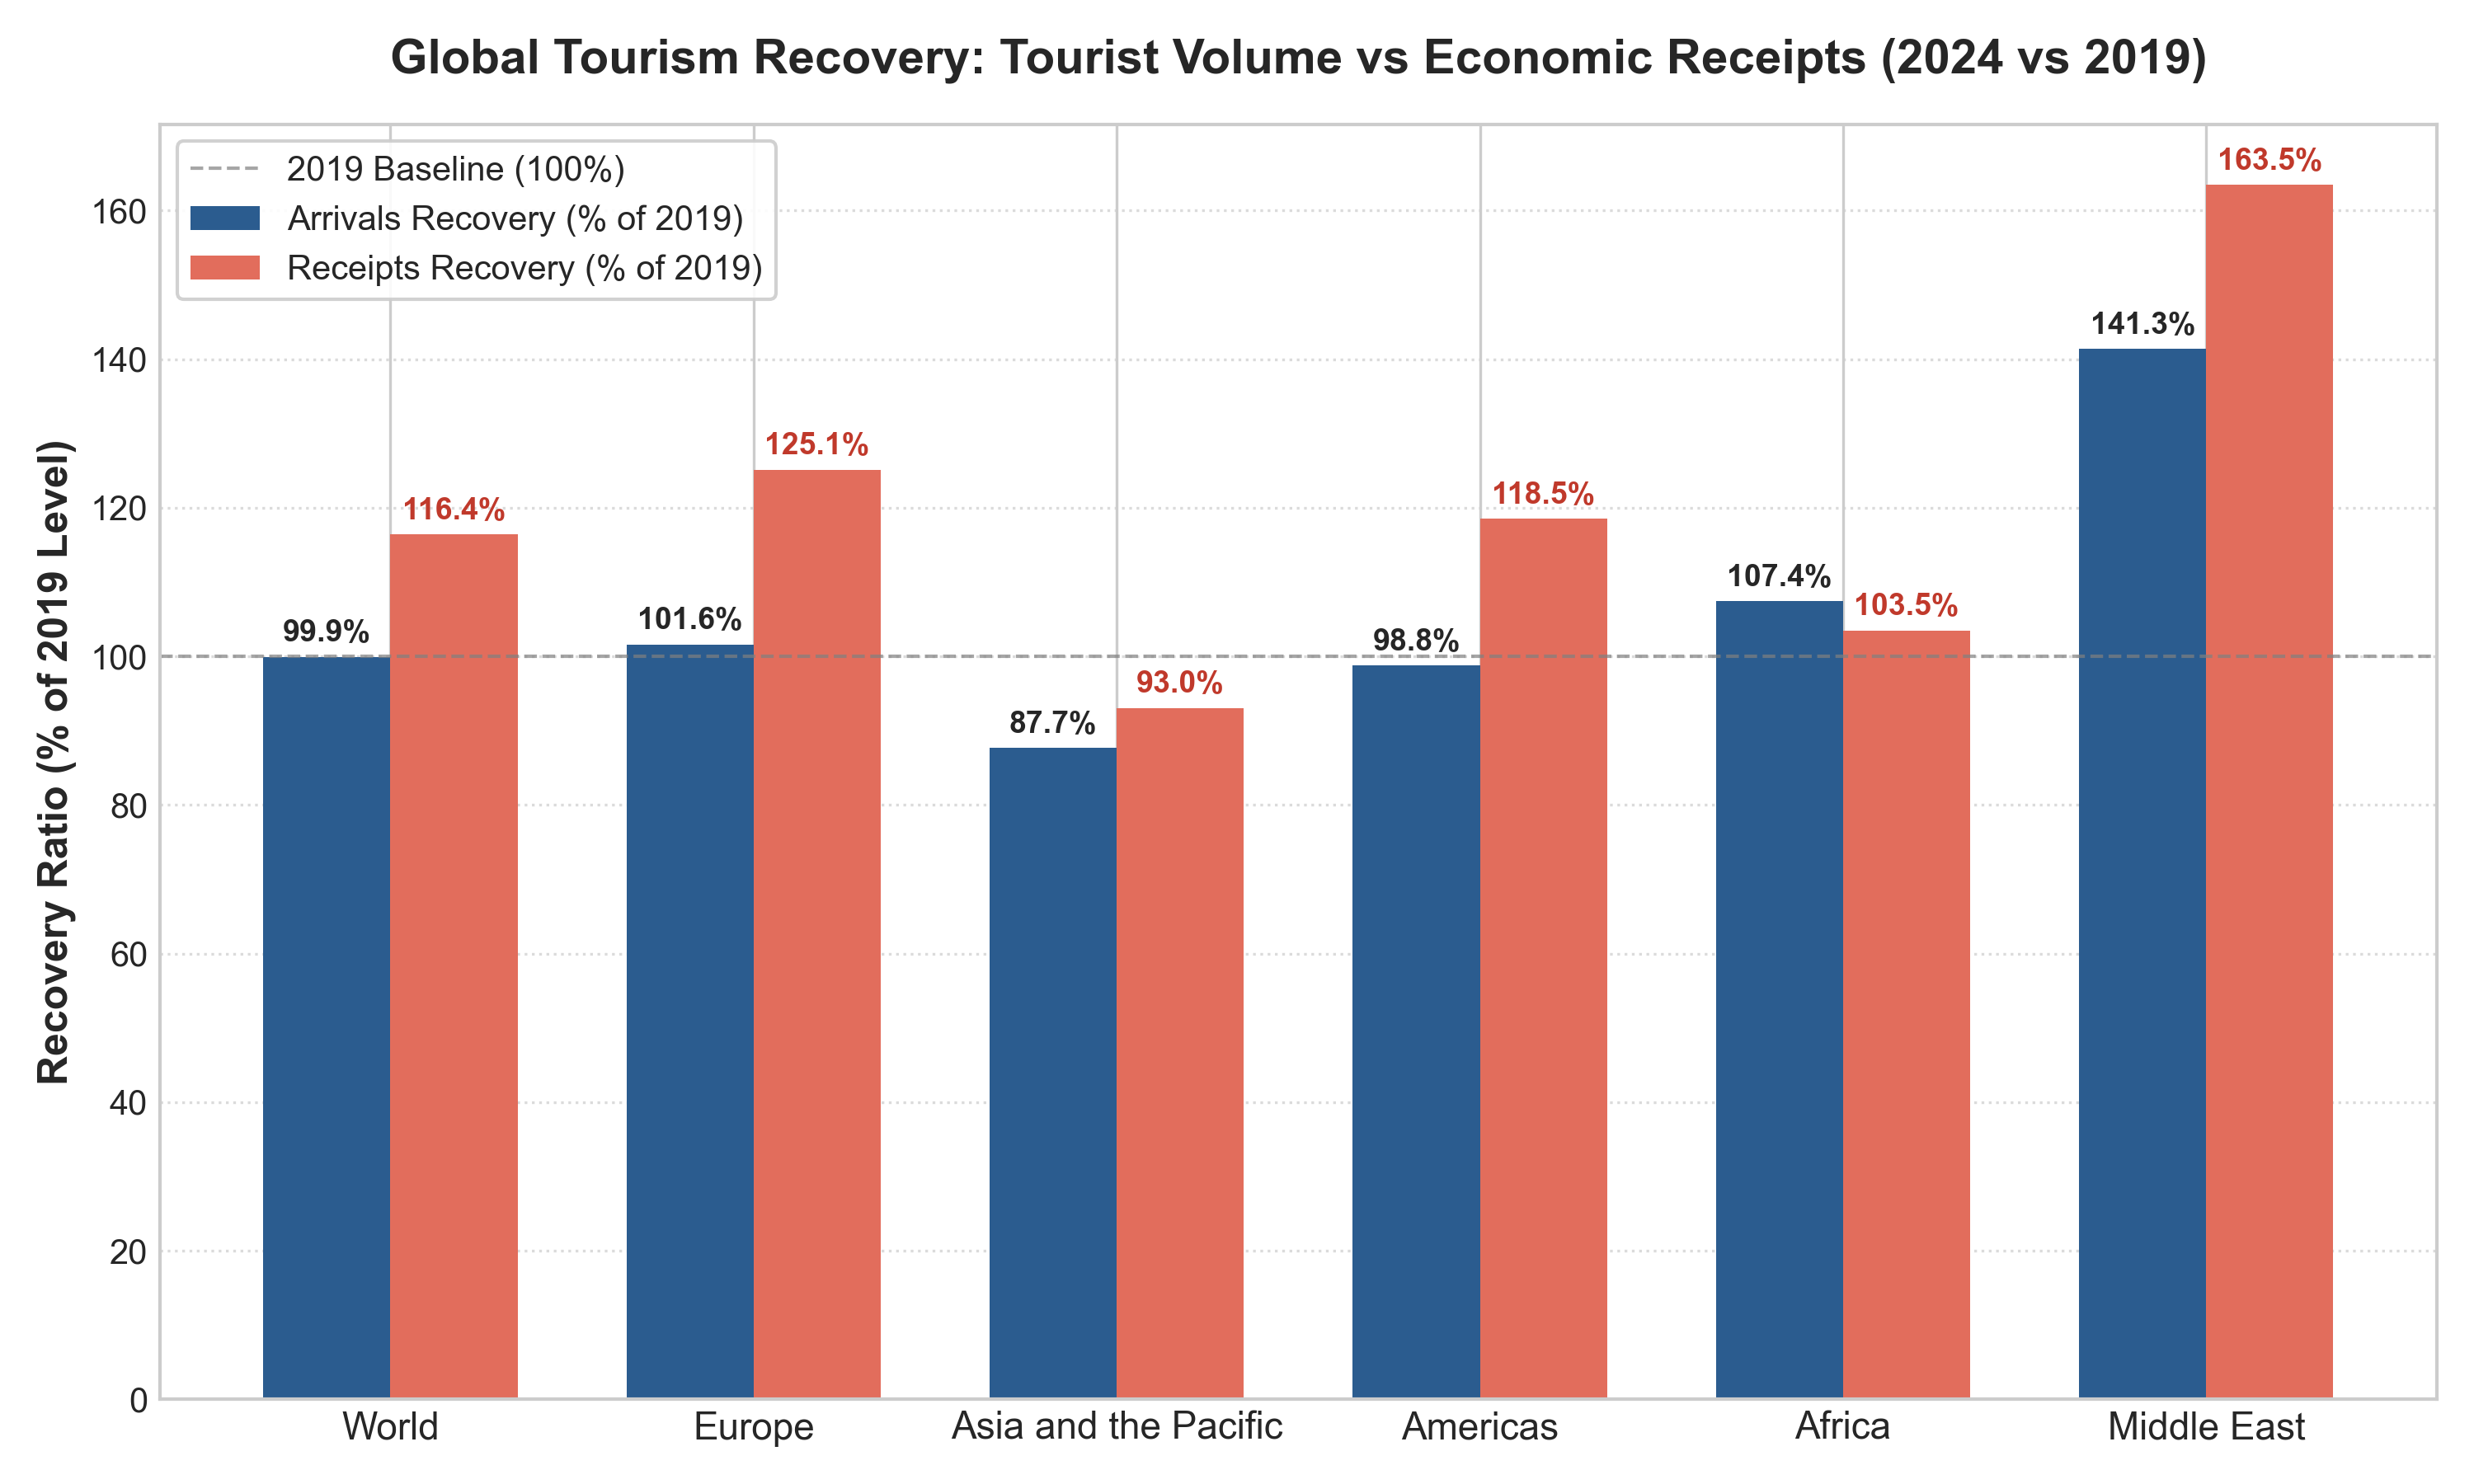

In [3]:
df_continents = df_global[df_global['Sub_Region'] == 'Total'].copy()
display_cols = [
    'Region', 'Arrivals_2019_M', 'Arrivals_2024_M', 'Arrivals_Recovery_24_vs_19_pct',
    'Receipts_2019_USD_B', 'Receipts_2024_USD_B', 'Receipts_Recovery_24_vs_19_pct',
    'Spend_Per_Arrival_2019_USD', 'Spend_Per_Arrival_2024_USD'
]
print("=== GLOBAL TOURISM RECOVERY BENCHMARKS (2024 vs 2019) ===")
print(df_continents[display_cols].sort_values('Receipts_Recovery_24_vs_19_pct', ascending=False).to_string())

world_arr_rec = df_continents.loc[df_continents['Region'] == 'World', 'Arrivals_Recovery_24_vs_19_pct'].values[0]
world_rec_rec = df_continents.loc[df_continents['Region'] == 'World', 'Receipts_Recovery_24_vs_19_pct'].values[0]

print("\nGlobal Key Findings:")
print(f"- World Tourist Arrivals in 2024 reached {world_arr_rec:.2f}% of 2019 baseline (1,465M vs 1,466M, -0.07%).")
print(f"- World Tourism Receipts reached {world_rec_rec:.2f}% of 2019 baseline ($1,731B vs $1,487B, +16.41%).")
print(f"- Average expenditure per arrival expanded from ${df_continents.loc[df_continents['Region'] == 'World', 'Spend_Per_Arrival_2019_USD'].values[0]:.2f} to ${df_continents.loc[df_continents['Region'] == 'World', 'Spend_Per_Arrival_2024_USD'].values[0]:.2f} (+16.49%).")



## 3. India Inbound Macro Trajectory & Methodological Series Break
### Research Questions Addressed:
- *RQ3*: How has India inbound tourism changed over the long term (2001-2024)?
- *RQ4*: How do FTAs, NRI arrivals, and ITAs diverge, and what was the impact of the 2014 reporting change?



=== DESCRIPTIVE STATISTICAL PROFILE (2001-2024) ===
                     mean      std      min       50%       max      IQR  Skewness
FTAs_Million         7.24     2.99     1.52      7.68     10.93     3.36     -0.74
ITAs_Million        12.24     5.73     2.54     13.76     20.57    10.34     -0.21
FEE_INR_Crore   145692.07 75719.13 15083.00 134843.00 293033.00 91351.50      0.40
FEE_USD_Million  21154.53  8771.13  3198.00  21012.00  35016.00 10127.00     -0.35

=== METHODOLOGICAL ANALYSIS: THE 2014 SERIES BREAK ===
1. Actual FTA Growth (2013 -> 2014): (7.68M - 6.97M) / 6.97M = +10.19%
2. Naive Mixed-Series Growth (using ITA in Table 1.1.2): (13.11M - 6.97M) / 6.97M = +88.09%
3. Artificial Distortion Magnitude: +77.91 percentage points!


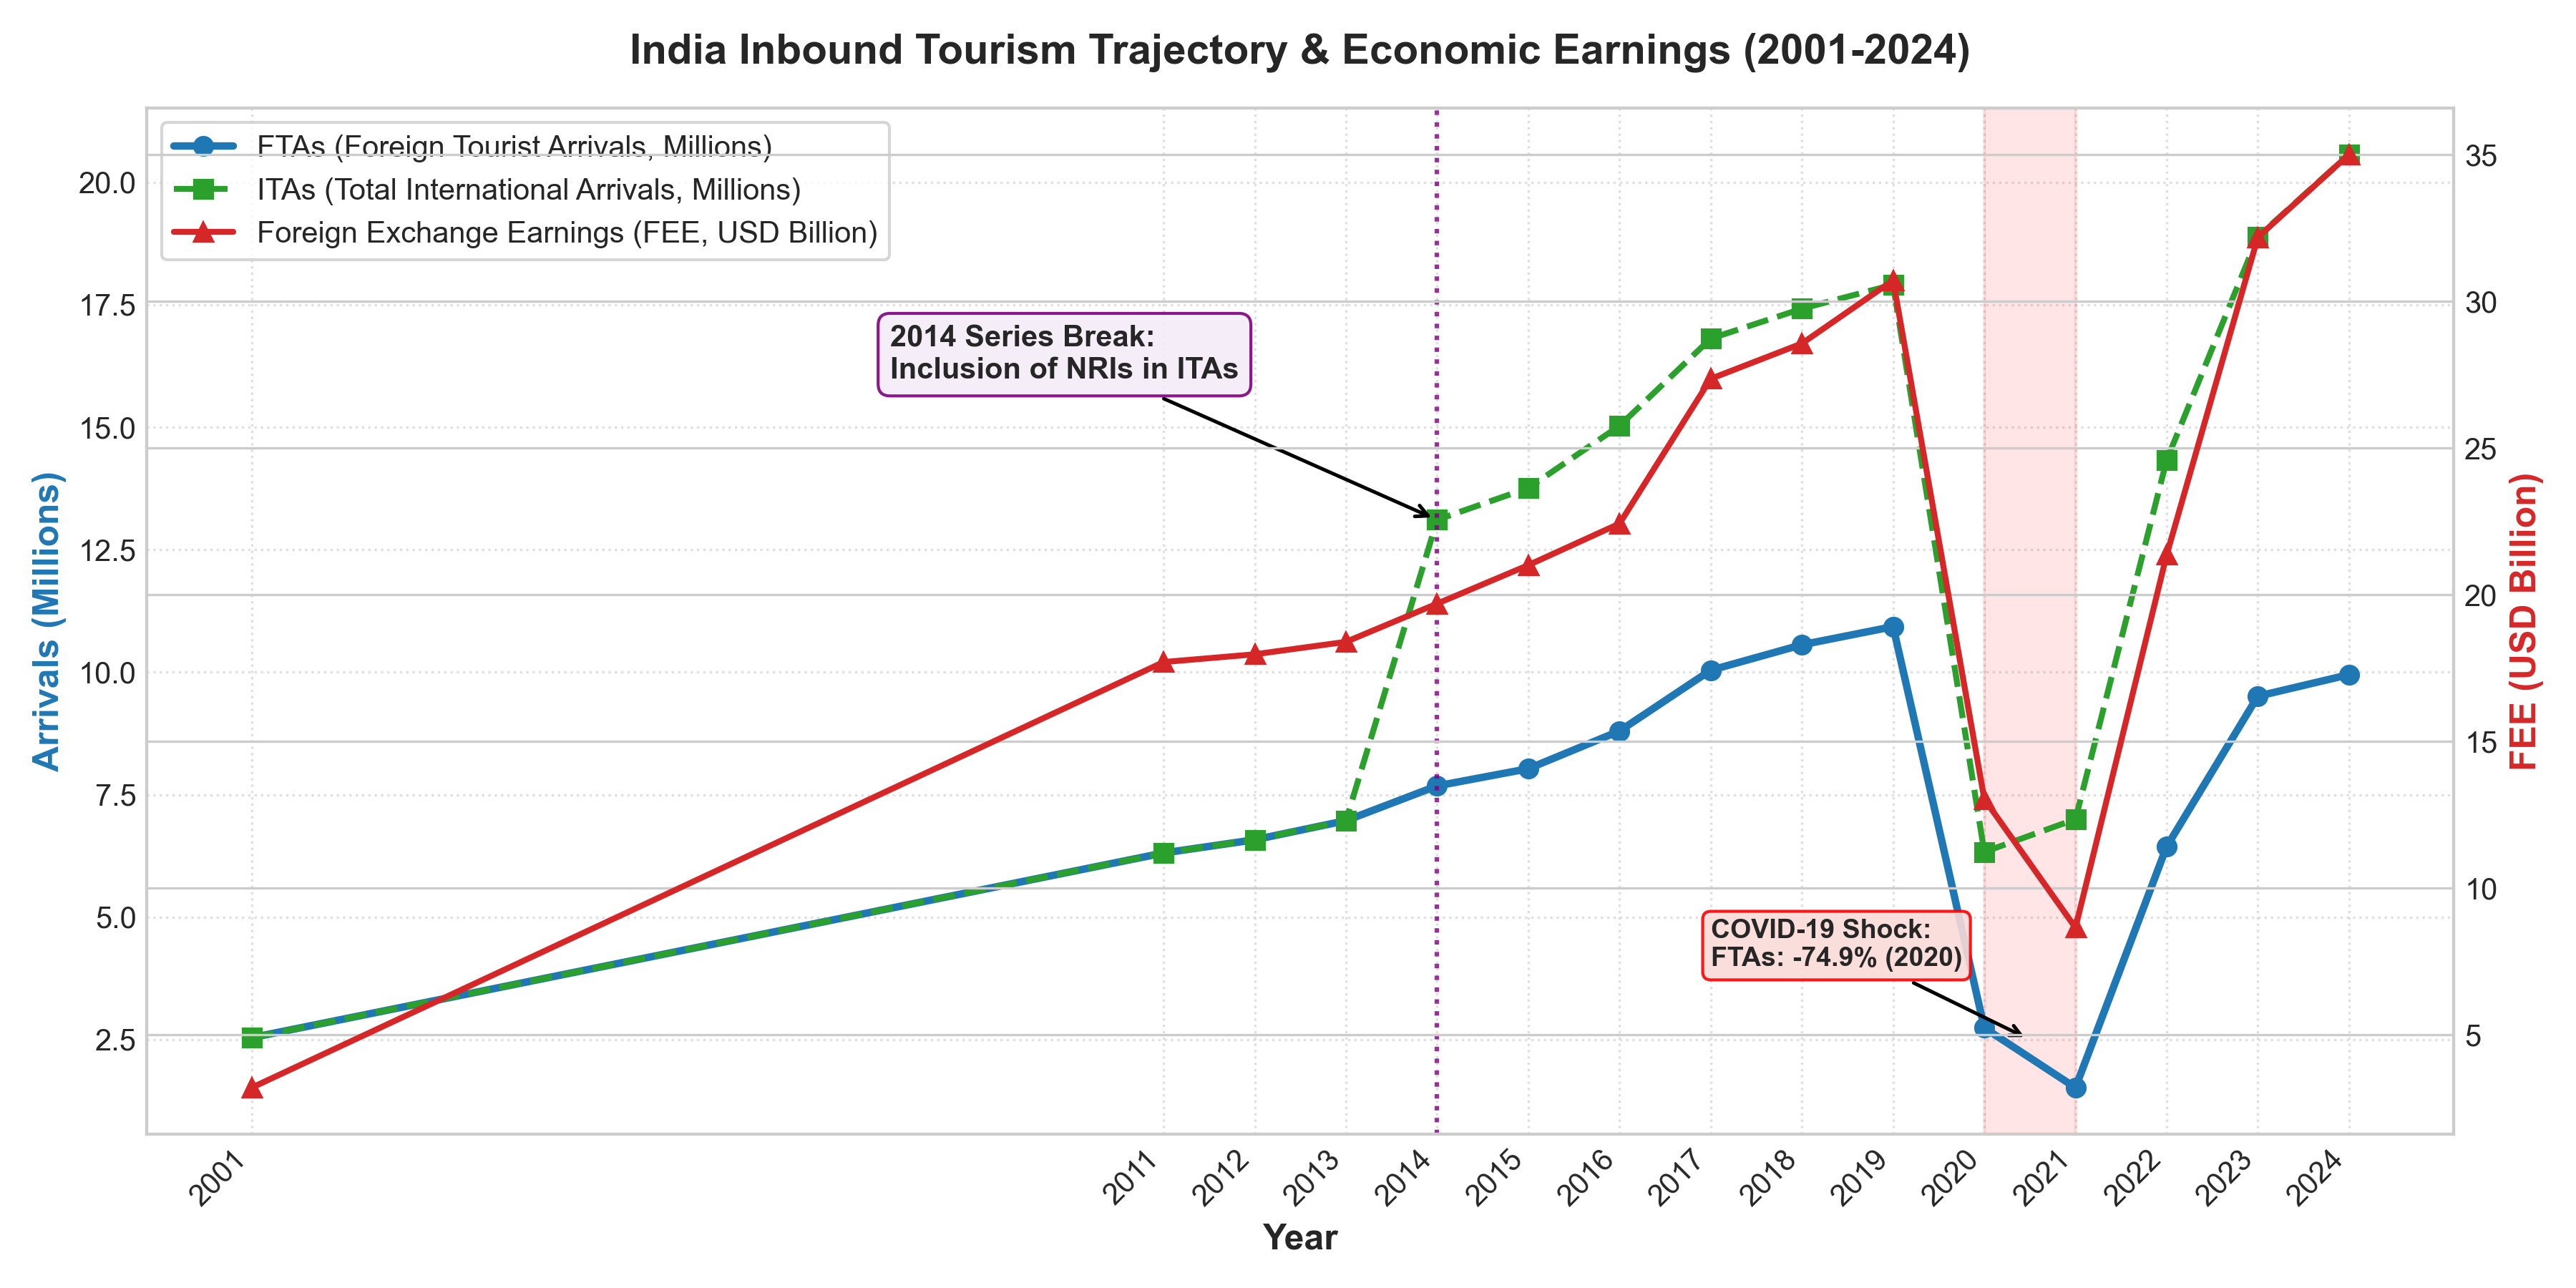

In [4]:
print("=== DESCRIPTIVE STATISTICAL PROFILE (2001-2024) ===")
inbound_stats = df_inbound[['FTAs_Million', 'ITAs_Million', 'FEE_INR_Crore', 'FEE_USD_Million']].describe().T
inbound_stats['IQR'] = inbound_stats['75%'] - inbound_stats['25%']
inbound_stats['Skewness'] = df_inbound[['FTAs_Million', 'ITAs_Million', 'FEE_INR_Crore', 'FEE_USD_Million']].skew()
print(inbound_stats[['mean', 'std', 'min', '50%', 'max', 'IQR', 'Skewness']].to_string())

print("\n=== METHODOLOGICAL ANALYSIS: THE 2014 SERIES BREAK ===")
fta_2013 = df_inbound.loc[df_inbound['Year'] == 2013, 'FTAs_Million'].values[0]
fta_2014 = df_inbound.loc[df_inbound['Year'] == 2014, 'FTAs_Million'].values[0]
ita_2014 = df_inbound.loc[df_inbound['Year'] == 2014, 'ITAs_Million'].values[0]

actual_fta_growth = ((fta_2014 - fta_2013) / fta_2013) * 100
unadjusted_ita_growth = ((ita_2014 - fta_2013) / fta_2013) * 100

print(f"1. Actual FTA Growth (2013 -> 2014): ({fta_2014:.2f}M - {fta_2013:.2f}M) / {fta_2013:.2f}M = +{actual_fta_growth:.2f}%")
print(f"2. Naive Mixed-Series Growth (using ITA in Table 1.1.2): ({ita_2014:.2f}M - {fta_2013:.2f}M) / {fta_2013:.2f}M = +{unadjusted_ita_growth:.2f}%")
print(f"3. Artificial Distortion Magnitude: +{unadjusted_ita_growth - actual_fta_growth:.2f} percentage points!")



## 4. Deep-Dive: FTA vs NRI Compositional Dynamics
From 2014 onward, the Ministry of Tourism separated arrivals into Foreign Tourist Arrivals (FTAs) and Non-Resident Indians (NRIs).



=== COMPOSITIONAL SPLIT: FTAs vs NRIs (2014-2024) ===
    Year  FTAs_Million  NRIs_Million  ITAs_Million  NRI_Share_of_ITAs_pct
4   2014          7.68          5.43         13.11                  41.43
5   2015          8.03          5.74         13.76                  41.68
6   2016          8.80          6.22         15.03                  41.41
7   2017         10.04          6.77         16.81                  40.29
8   2018         10.56          6.87         17.42                  39.41
9   2019         10.93          6.98         17.91                  38.98
10  2020          2.74          3.59          6.33                  56.68
11  2021          1.52          5.48          7.00                  78.20
12  2022          6.44          7.89         14.33                  55.07
13  2023          9.51          9.38         18.89                  49.62
14  2024          9.95         10.62         20.57                  51.62

Critical Empirical Finding:
- FTA Recovery (2024 vs 2019)

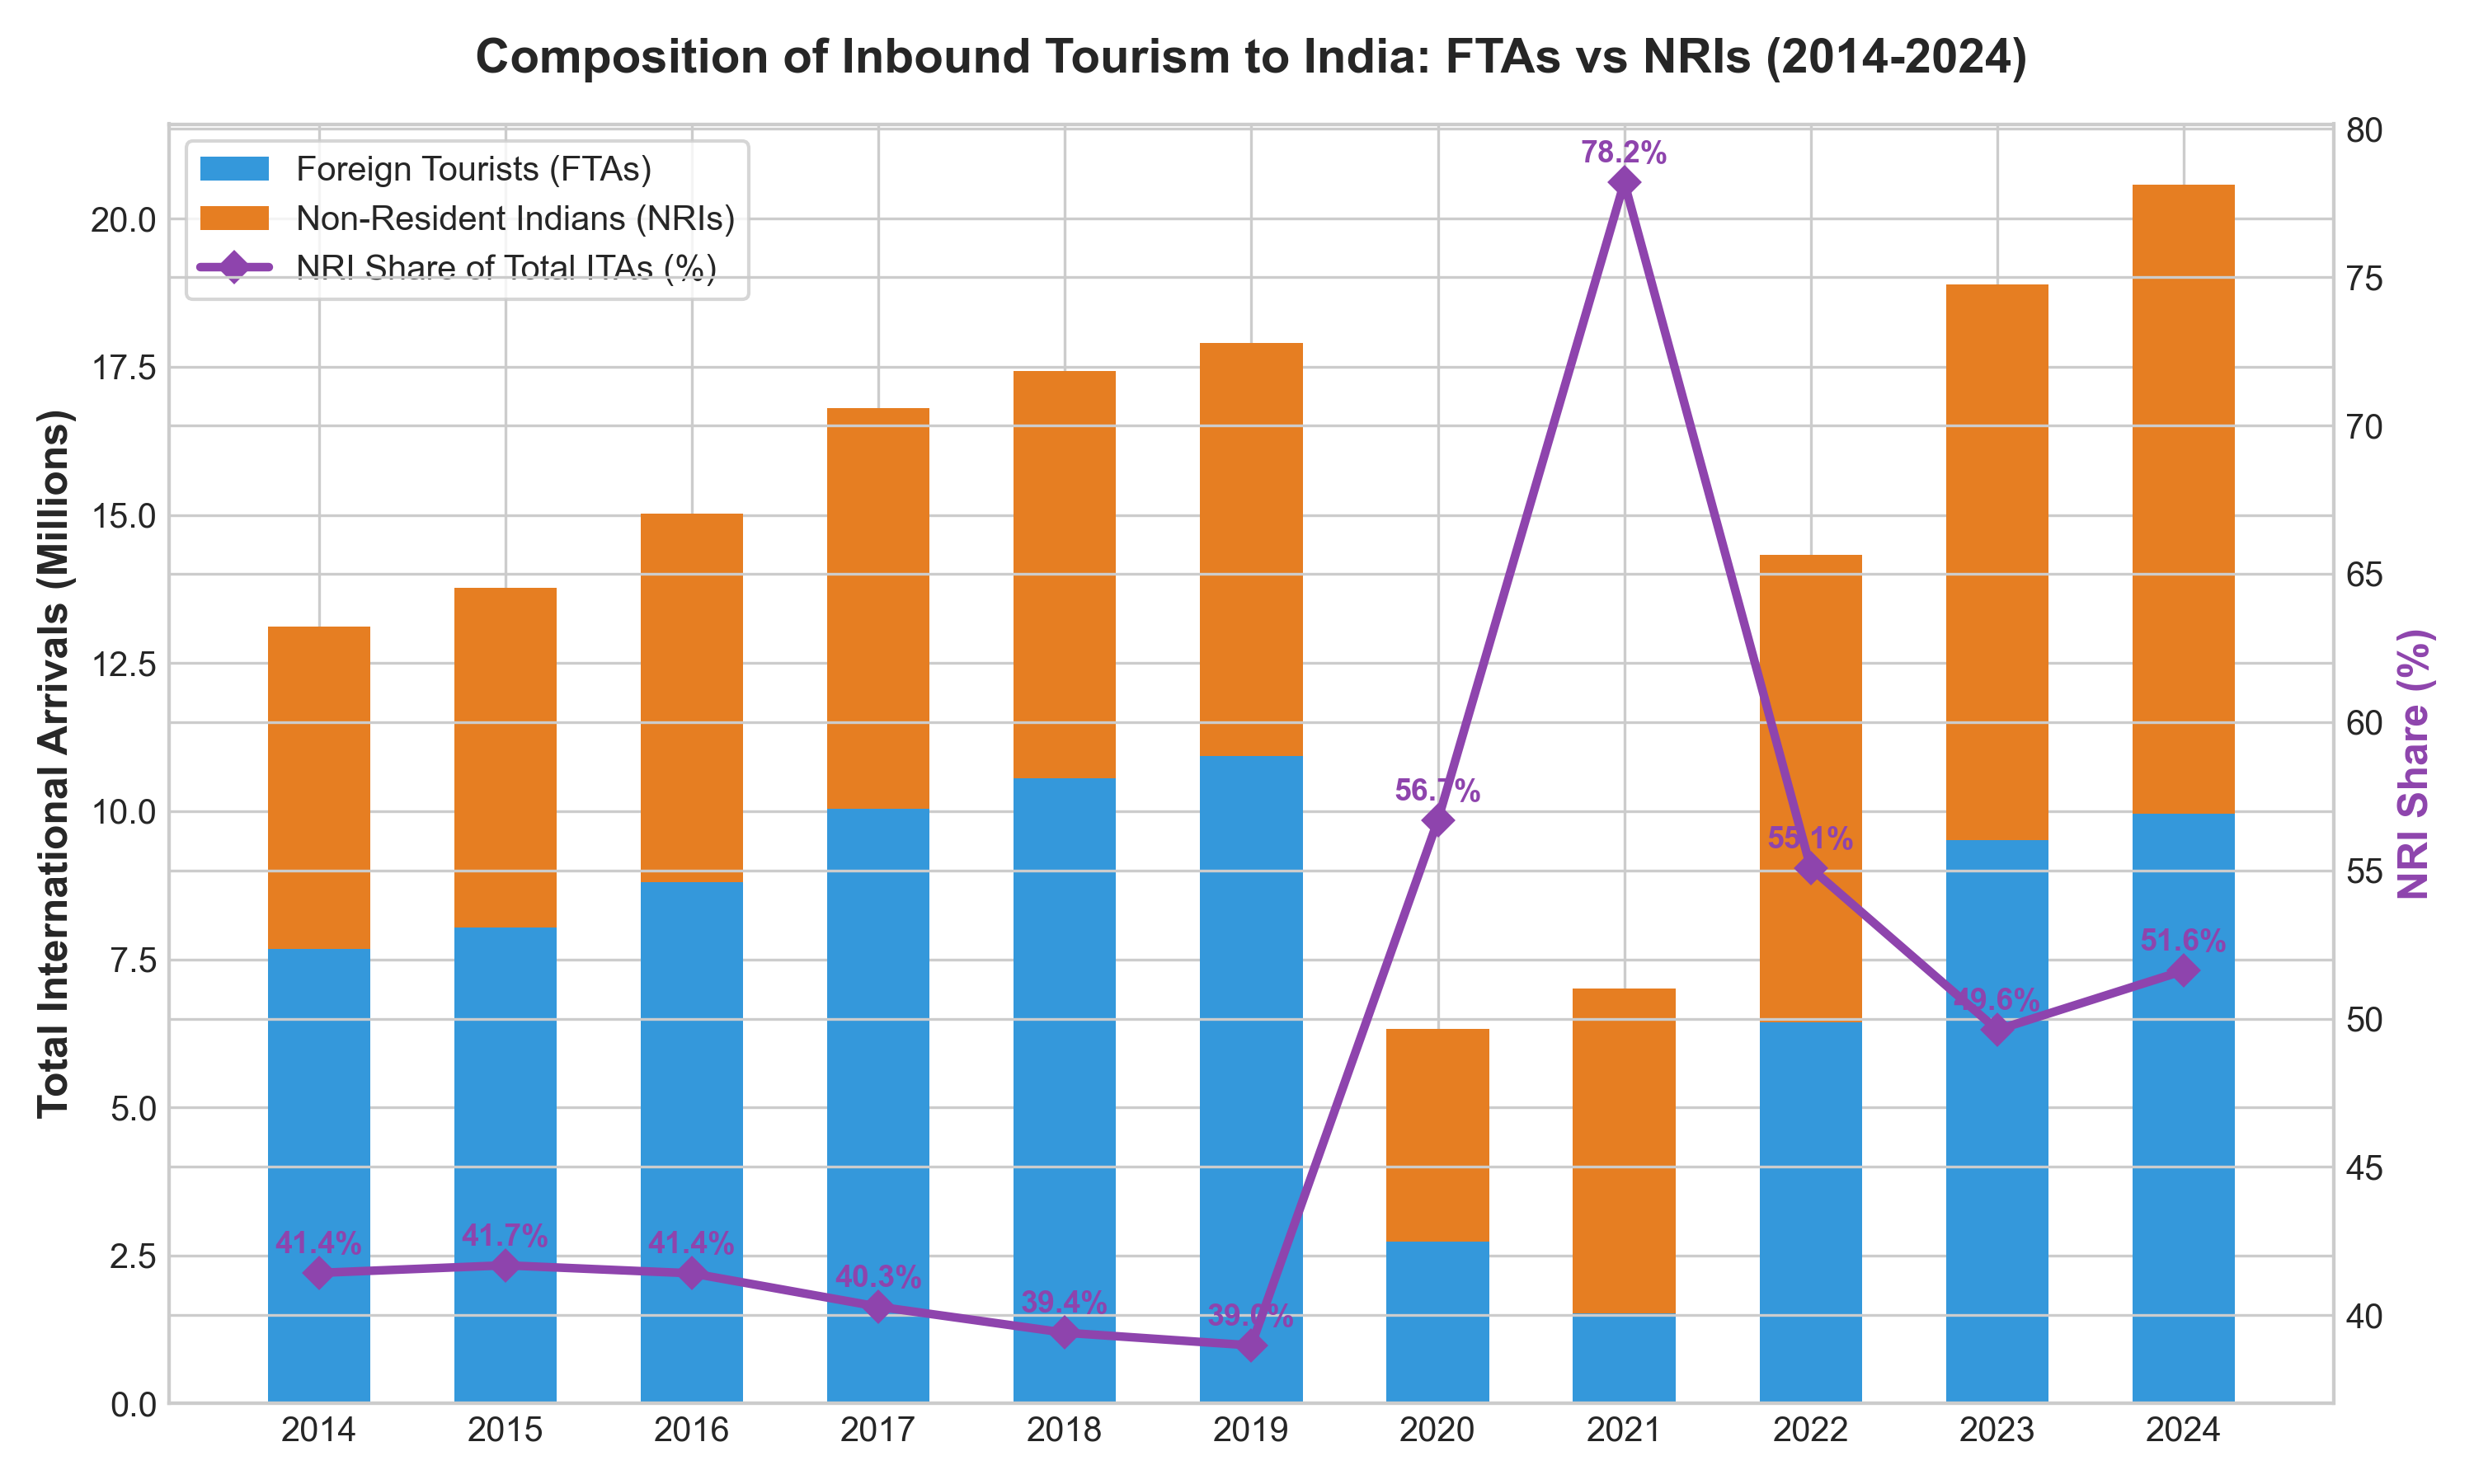

In [5]:
df_post2014 = df_inbound[df_inbound['Year'] >= 2014].copy()
print("=== COMPOSITIONAL SPLIT: FTAs vs NRIs (2014-2024) ===")
print(df_post2014[['Year', 'FTAs_Million', 'NRIs_Million', 'ITAs_Million', 'NRI_Share_of_ITAs_pct']].to_string())

fta_rec_india = (df_inbound.loc[df_inbound['Year'] == 2024, 'FTAs_Exact'].values[0] / df_inbound.loc[df_inbound['Year'] == 2019, 'FTAs_Exact'].values[0]) * 100
nri_rec_india = (df_inbound.loc[df_inbound['Year'] == 2024, 'NRIs_Exact'].values[0] / df_inbound.loc[df_inbound['Year'] == 2019, 'NRIs_Exact'].values[0]) * 100
ita_rec_india = (df_inbound.loc[df_inbound['Year'] == 2024, 'ITAs_Exact'].values[0] / df_inbound.loc[df_inbound['Year'] == 2019, 'ITAs_Exact'].values[0]) * 100

print("\nCritical Empirical Finding:")
print(f"- FTA Recovery (2024 vs 2019): {fta_rec_india:.2f}% (Contraction of -{100 - fta_rec_india:.2f}%, deficit of 978,633 foreign tourists)")
print(f"- NRI Recovery (2024 vs 2019): {nri_rec_india:.2f}% (Expansion of +{nri_rec_india - 100:.2f}%, surplus of 3,633,741 diaspora visits)")
print(f"- ITA Recovery (2024 vs 2019): {ita_rec_india:.2f}% (Apparent expansion of +{ita_rec_india - 100:.2f}%)")
print(f"- NRI arrivals expanded to constitute {df_inbound.loc[df_inbound['Year'] == 2024, 'NRI_Share_of_ITAs_pct'].values[0]:.2f}% of all international entries in 2024.")



## 5. Source Market Concentration & Exposure Risk
### Research Question Addressed:
- *RQ5*: Which source countries and regions contribute the largest share of FTAs to India, and how concentrated is market dependency?



=== TOP 15 SOURCE COUNTRIES RECOVERY AND MARKET SHARE ===
    Rank_2024             Country  FTAs_2019  FTAs_2024  Share_2024_pct  Growth_24_vs_23_pct  Recovery_24_vs_19_pct
0           1       United States    1512032    1804586           18.13                 6.69                 119.35
1           2          Bangladesh    2577727    1750165           17.59               -17.44                  67.90
2           3      United Kingdom    1000292    1022587           10.28                11.08                 102.23
3           4           Australia     367241     518205            5.21                13.60                 141.11
4           5              Canada     351859     476273            4.79                23.41                 135.36
5           6            Malaysia     334579     307526            3.09                17.17                  91.91
6           7           Sri Lanka     330861     281827            2.83                 0.54                  85.18
7           8 

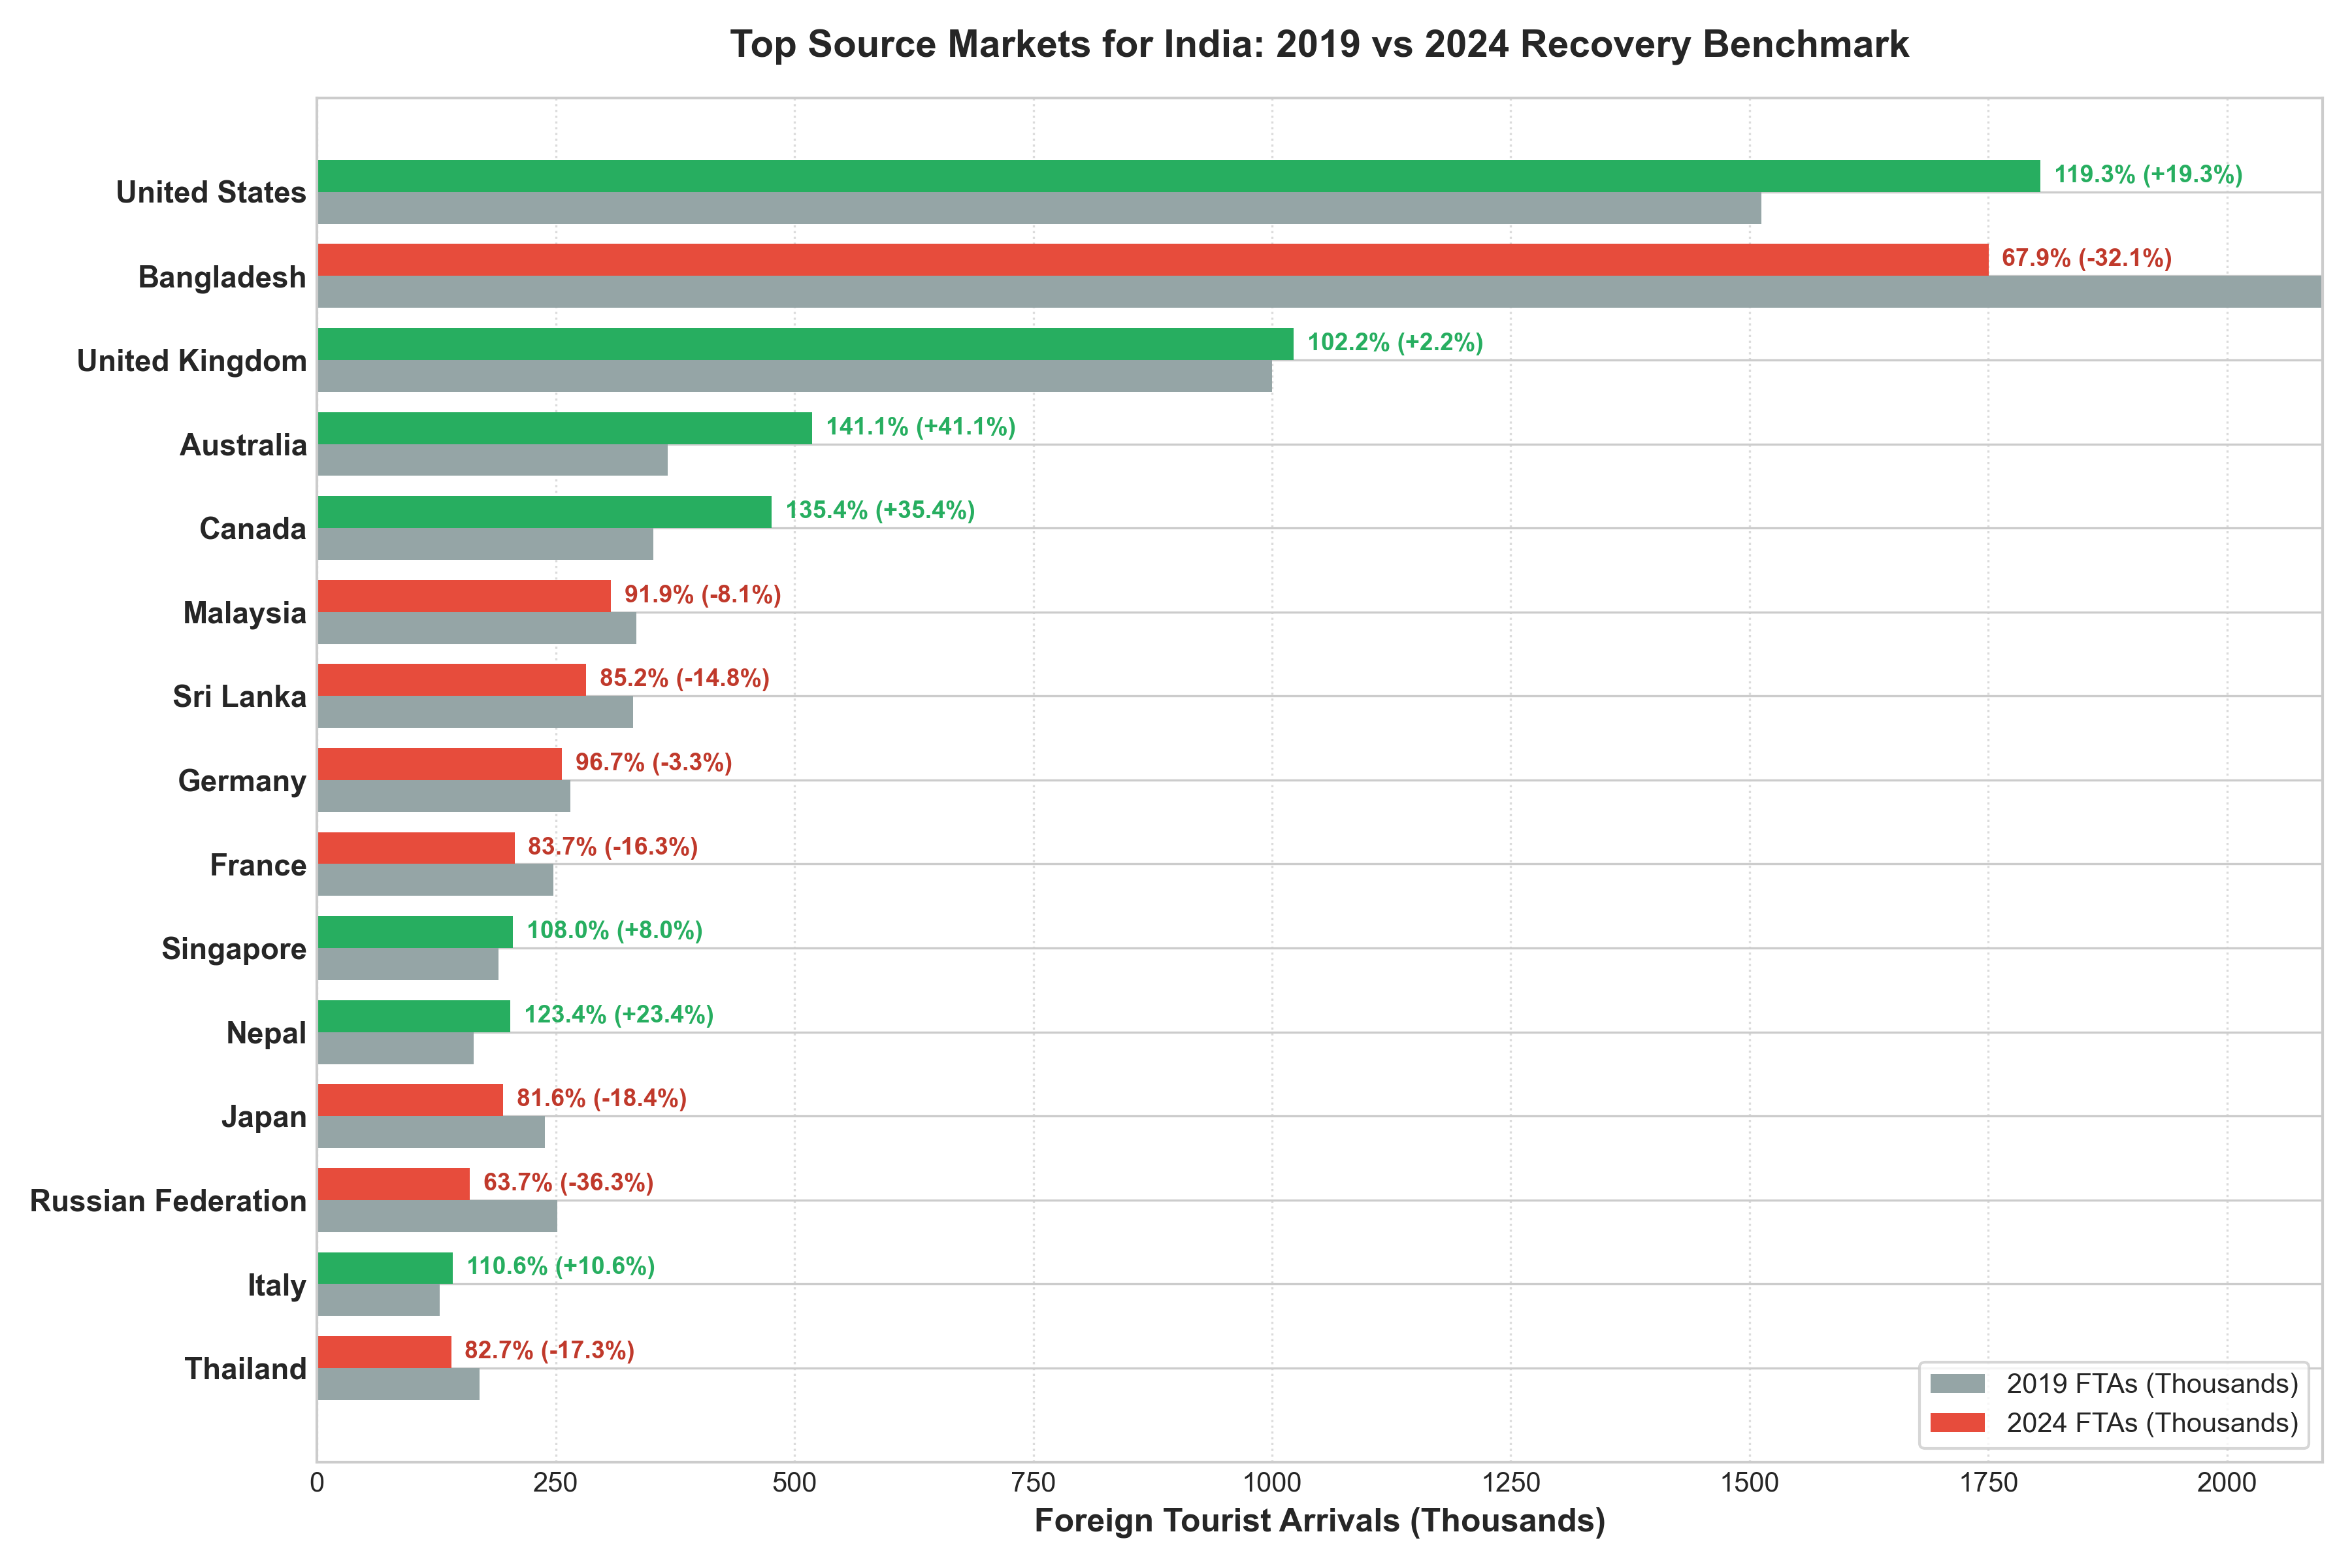

In [6]:
print("=== TOP 15 SOURCE COUNTRIES RECOVERY AND MARKET SHARE ===")
print(df_top.sort_values('Rank_2024')[['Rank_2024', 'Country', 'FTAs_2019', 'FTAs_2024', 'Share_2024_pct', 'Growth_24_vs_23_pct', 'Recovery_24_vs_19_pct']].to_string())

cr3_2024 = df_top.sort_values('FTAs_2024', ascending=False).head(3)['Share_2024_pct'].sum()
cr5_2024 = df_top.sort_values('FTAs_2024', ascending=False).head(5)['Share_2024_pct'].sum()
cr10_2024 = df_top.sort_values('FTAs_2024', ascending=False).head(10)['Share_2024_pct'].sum()

hhi_2024 = (df_top['Share_2024_pct'] ** 2).sum()
hhi_2019 = (df_top['Share_2019_pct'] ** 2).sum()

print("\n=== CONCENTRATION METRICS SUMMARY ===")
print(f"- CR3 (Top 3 Share: USA, Bangladesh, UK): {cr3_2024:.2f}%")
print(f"- CR5 (Top 5 Share: + Australia, Canada): {cr5_2024:.2f}%")
print(f"- CR10 (Top 10 Share): {cr10_2024:.2f}%")
print(f"- Herfindahl-Hirschman Index (HHI): 2019 = {hhi_2019:.1f} | 2024 = {hhi_2024:.1f}")

bg_drop = df_top.loc[df_top['Country'] == 'Bangladesh', 'FTAs_2019'].values[0] - df_top.loc[df_top['Country'] == 'Bangladesh', 'FTAs_2024'].values[0]
china_drop = df_top.loc[df_top['Country'] == 'China', 'FTAs_2019'].values[0] - df_top.loc[df_top['Country'] == 'China', 'FTAs_2024'].values[0]
total_national_drop = 10930355 - 9951722

print("\n=== ANOMALY & CONTRACTION DRIVERS ===")
print(f"- Total National FTA Deficit (2024 vs 2019): {total_national_drop:,} tourists")
print(f"- Bangladesh Contraction alone: {bg_drop:,} tourists ({bg_drop/total_national_drop * 100:.1f}% of national deficit)")
print(f"- China Contraction alone: {china_drop:,} tourists ({china_drop/total_national_drop * 100:.1f}% of national deficit)")
print(f"- Combined Bangladesh + China deficit: {(bg_drop + china_drop)/total_national_drop * 100:.1f}% of India unrecovered arrivals.")



## 6. Seasonality Modeling & Temporal Dichotomy
### Research Question Addressed:
- *RQ6*: What seasonal patterns characterize inbound tourism, and how do seasonal cycles differ between Foreign Tourists (FTAs) and Non-Resident Indians (NRIs)?



=== MONTHLY DISTRIBUTION & SEASONALITY INDICES (2024) ===
        Month Quarter  FTAs_2024  FTA_Share_2024_pct  FTA_Seasonality_Index_2024  NRIs_2024  NRI_Seasonality_Index_2024  ITAs_2024  ITA_Seasonality_Index_2024
0     January      Q1     981609                9.86                      118.36     790718                       89.37    1772327                      103.40
1    February      Q1    1032301               10.37                      124.48     704683                       79.65    1736984                      101.34
2       March      Q1     893021                8.97                      107.68     818820                       92.55    1711841                       99.87
3       April      Q2     672684                6.76                       81.11     864188                       97.68    1536872                       89.66
4         May      Q2     622189                6.25                       75.02     854480                       96.58    1476669                 

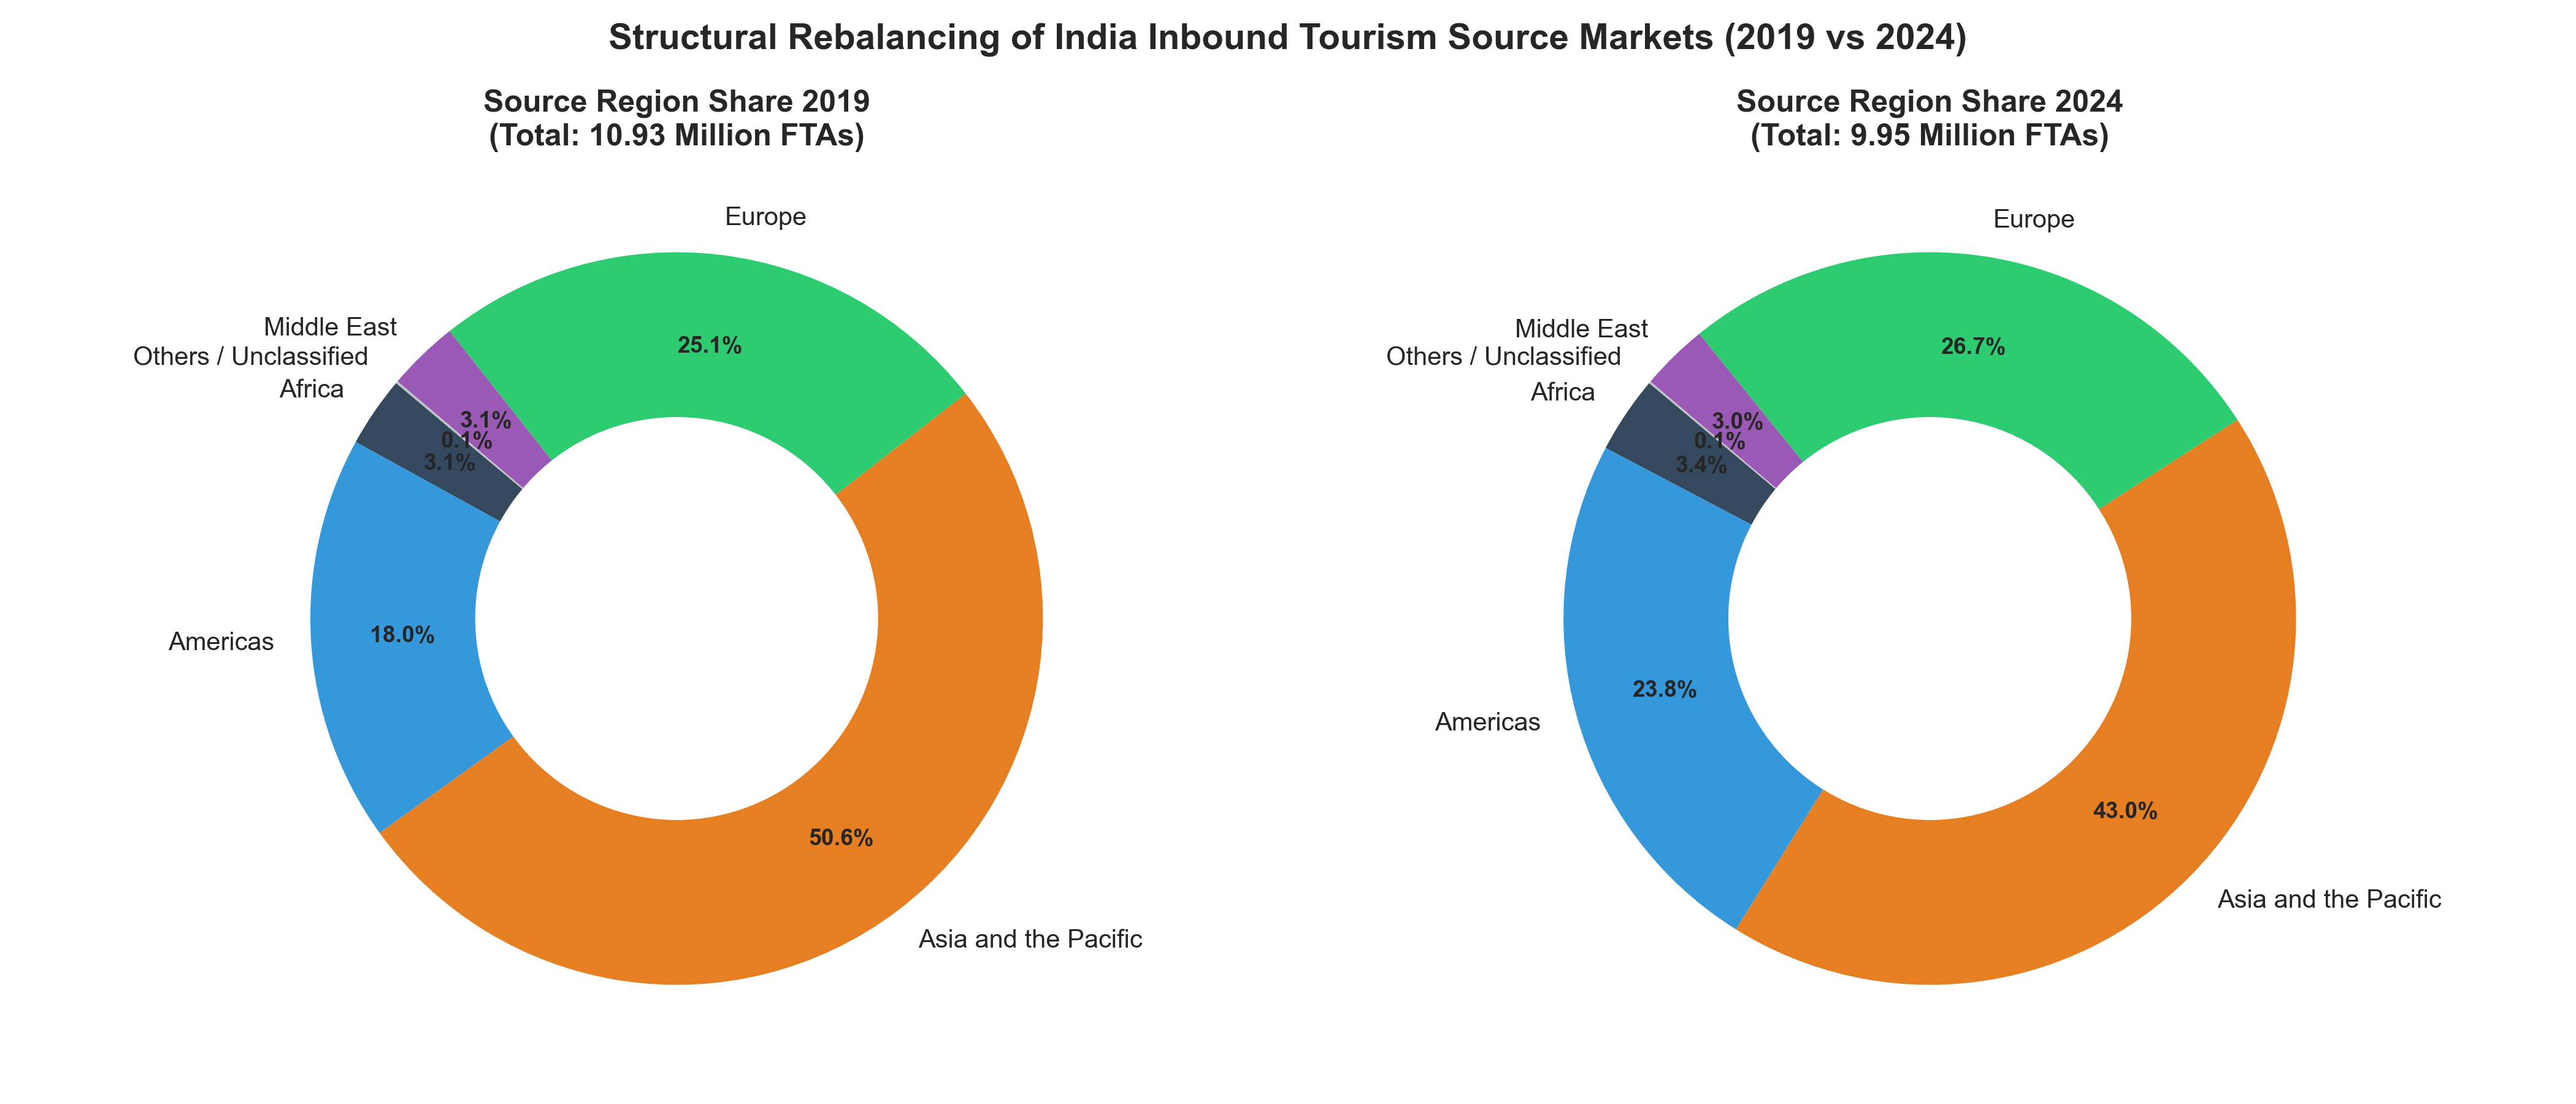

In [7]:
print("=== MONTHLY DISTRIBUTION & SEASONALITY INDICES (2024) ===")
print(df_monthly[['Month', 'Quarter', 'FTAs_2024', 'FTA_Share_2024_pct', 'FTA_Seasonality_Index_2024',
                 'NRIs_2024', 'NRI_Seasonality_Index_2024', 'ITAs_2024', 'ITA_Seasonality_Index_2024']].to_string())

fta_peak_idx = df_monthly['FTA_Seasonality_Index_2024'].max()
fta_lean_idx = df_monthly['FTA_Seasonality_Index_2024'].min()
fta_peak_month = df_monthly.loc[df_monthly['FTA_Seasonality_Index_2024'].idxmax(), 'Month']
fta_lean_month = df_monthly.loc[df_monthly['FTA_Seasonality_Index_2024'].idxmin(), 'Month']
fta_ratio = df_monthly['FTAs_2024'].max() / df_monthly['FTAs_2024'].min()

nri_peak_idx = df_monthly['NRI_Seasonality_Index_2024'].max()
nri_lean_idx = df_monthly['NRI_Seasonality_Index_2024'].min()
nri_peak_month = df_monthly.loc[df_monthly['NRI_Seasonality_Index_2024'].idxmax(), 'Month']
nri_lean_month = df_monthly.loc[df_monthly['NRI_Seasonality_Index_2024'].idxmin(), 'Month']
nri_ratio = df_monthly['NRIs_2024'].max() / df_monthly['NRIs_2024'].min()

print("\n=== SEASONALITY VOLATILITY METRICS ===")
print(f"- FTAs: Peak Month = {fta_peak_month} (SI = {fta_peak_idx:.1f}) | Lean Month = {fta_lean_month} (SI = {fta_lean_idx:.1f}) | Peak-to-Lean Ratio = {fta_ratio:.2f}x")
print(f"- NRIs: Peak Month = {nri_peak_month} (SI = {nri_peak_idx:.1f}) | Lean Month = {nri_lean_month} (SI = {nri_lean_idx:.1f}) | Peak-to-Lean Ratio = {nri_ratio:.2f}x")



## 7. Gateway Logistics & Entry Port Capacity
### Research Question Addressed:
- *RQ7*: Through which modes and ports do foreign tourists enter India, and which entry points dominate infrastructural capacity?



=== HISTORICAL TRAVEL MODE EVOLUTION (2001-2024) ===
    Year  Air_pct  Land_pct  Water_pct
0   2001    87.10     12.00       0.90
1   2011    92.00      7.20       0.80
2   2014    86.10     13.50       0.40
3   2016    84.10     15.00       0.90
4   2017    79.60     19.70       0.70
5   2018    79.60     19.60       0.80
6   2019    77.40     21.70       0.90
7   2020    79.20     19.30       1.50
8   2021    87.49     11.80       0.70
9   2022    83.50     16.20       0.30
10  2023    79.40     20.10       0.50
11  2024    83.41     16.05       0.54

=== AIRPORT GATEWAY CONCENTRATION (TOP 10, 2024) ===
           Airport     FTAs  Share_pct  Cumulative_Share
0            Delhi  3224675      38.85             38.85
1           Mumbai  1557196      18.76             57.61
2          Chennai   814594       9.81             67.42
3        Bengaluru   696924       8.40             75.82
4        Hyderabad   394824       4.76             80.58
5           Cochin   372217       4.48      

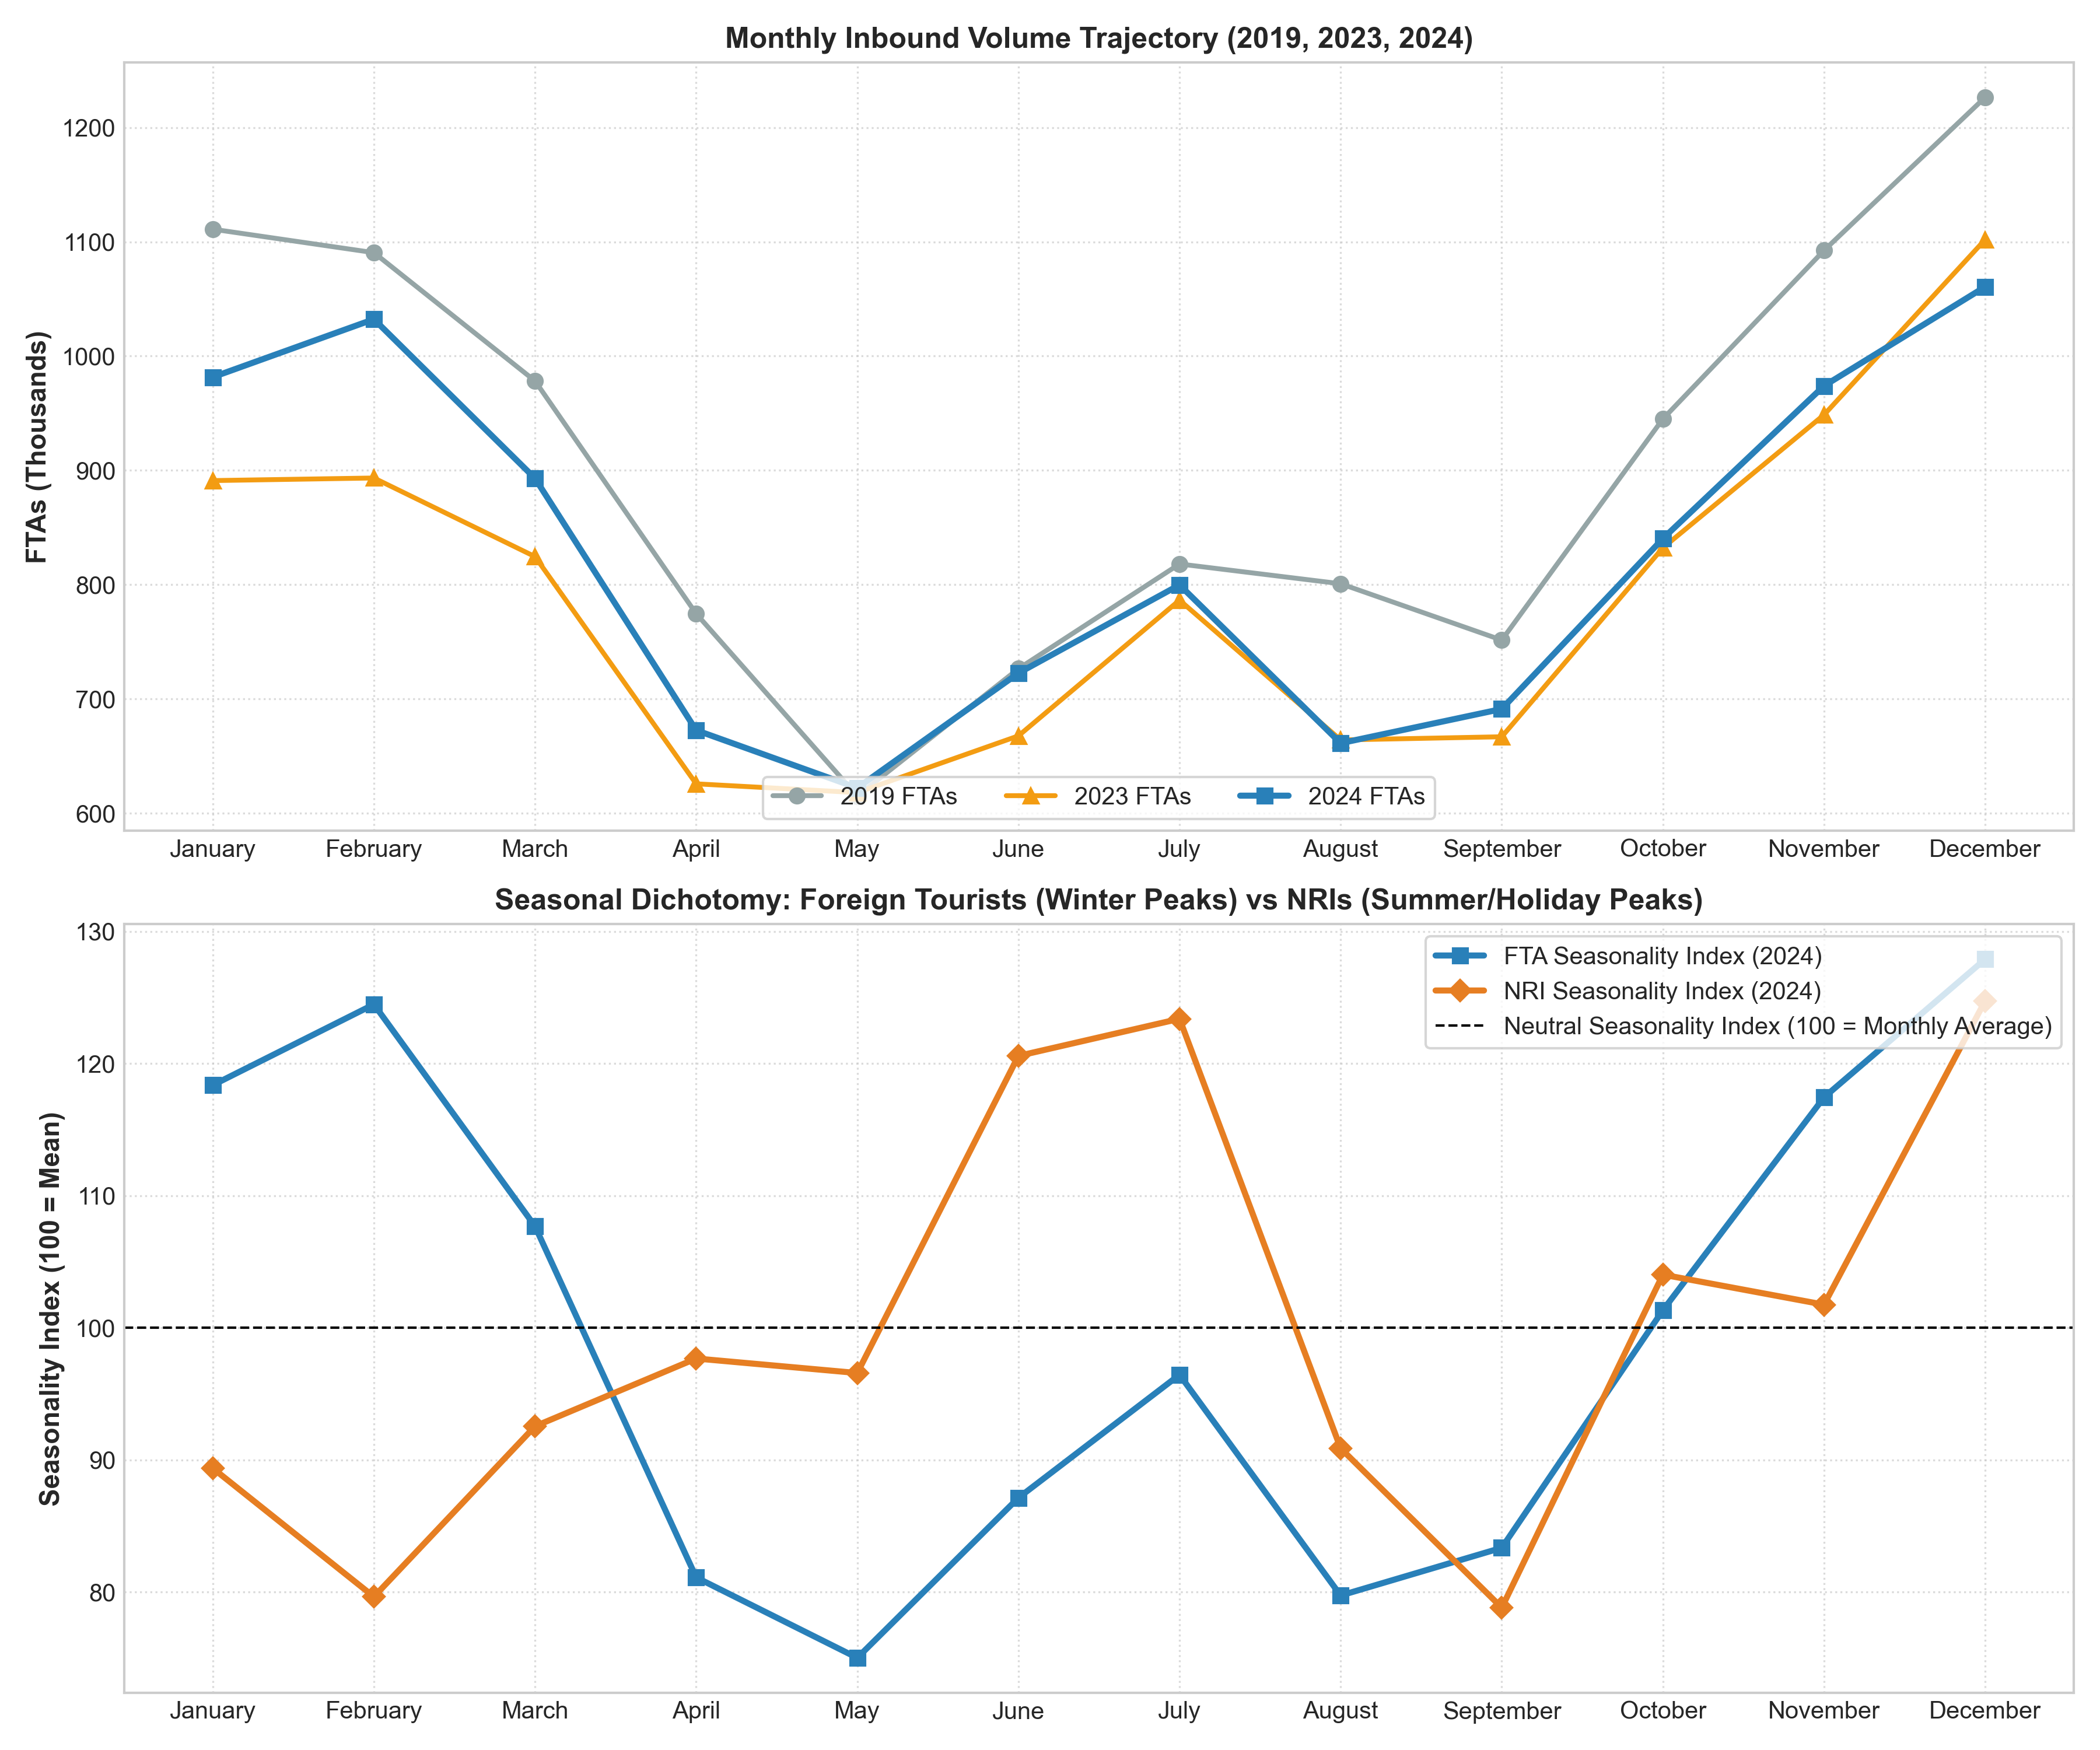

In [8]:
print("=== HISTORICAL TRAVEL MODE EVOLUTION (2001-2024) ===")
print(df_ports[['Year', 'Air_pct', 'Land_pct', 'Water_pct']].to_string())

airports_data = [
    ('Delhi', 3224675, 38.85), ('Mumbai', 1557196, 18.76), ('Chennai', 814594, 9.81),
    ('Bengaluru', 696924, 8.40), ('Hyderabad', 394824, 4.76), ('Cochin', 372217, 4.48),
    ('Kolkata', 276667, 3.33), ('Ahmedabad', 219993, 2.65), ('Amritsar', 148237, 1.79),
    ('Tiruchirappalli', 116499, 1.40)
]
df_air = pd.DataFrame(airports_data, columns=['Airport', 'FTAs', 'Share_pct'])
df_air['Cumulative_Share'] = df_air['Share_pct'].cumsum()
print("\n=== AIRPORT GATEWAY CONCENTRATION (TOP 10, 2024) ===")
print(df_air.to_string())



## 8. Monetization & Economic Elasticity Analysis
We evaluate the relationship between Foreign Exchange Earnings (FEE) and arrival counts.



=== ECONOMIC VALUATION & YIELD DYNAMICS (2024 vs 2019) ===
- FTA Volume Growth: -8.95%
- FEE Earnings Growth (USD Terms): +13.98% ($30,721M -> $35,016M)
- FEE Earnings Growth (INR Terms): +35.37% (Rs 2,16,467 Cr -> Rs 2,93,033 Cr)
- Revenue Yield per FTA (USD): 2019 = $2810.61 | 2024 = $3518.59 (+25.0%)
- Economic Elasticity: -1.56


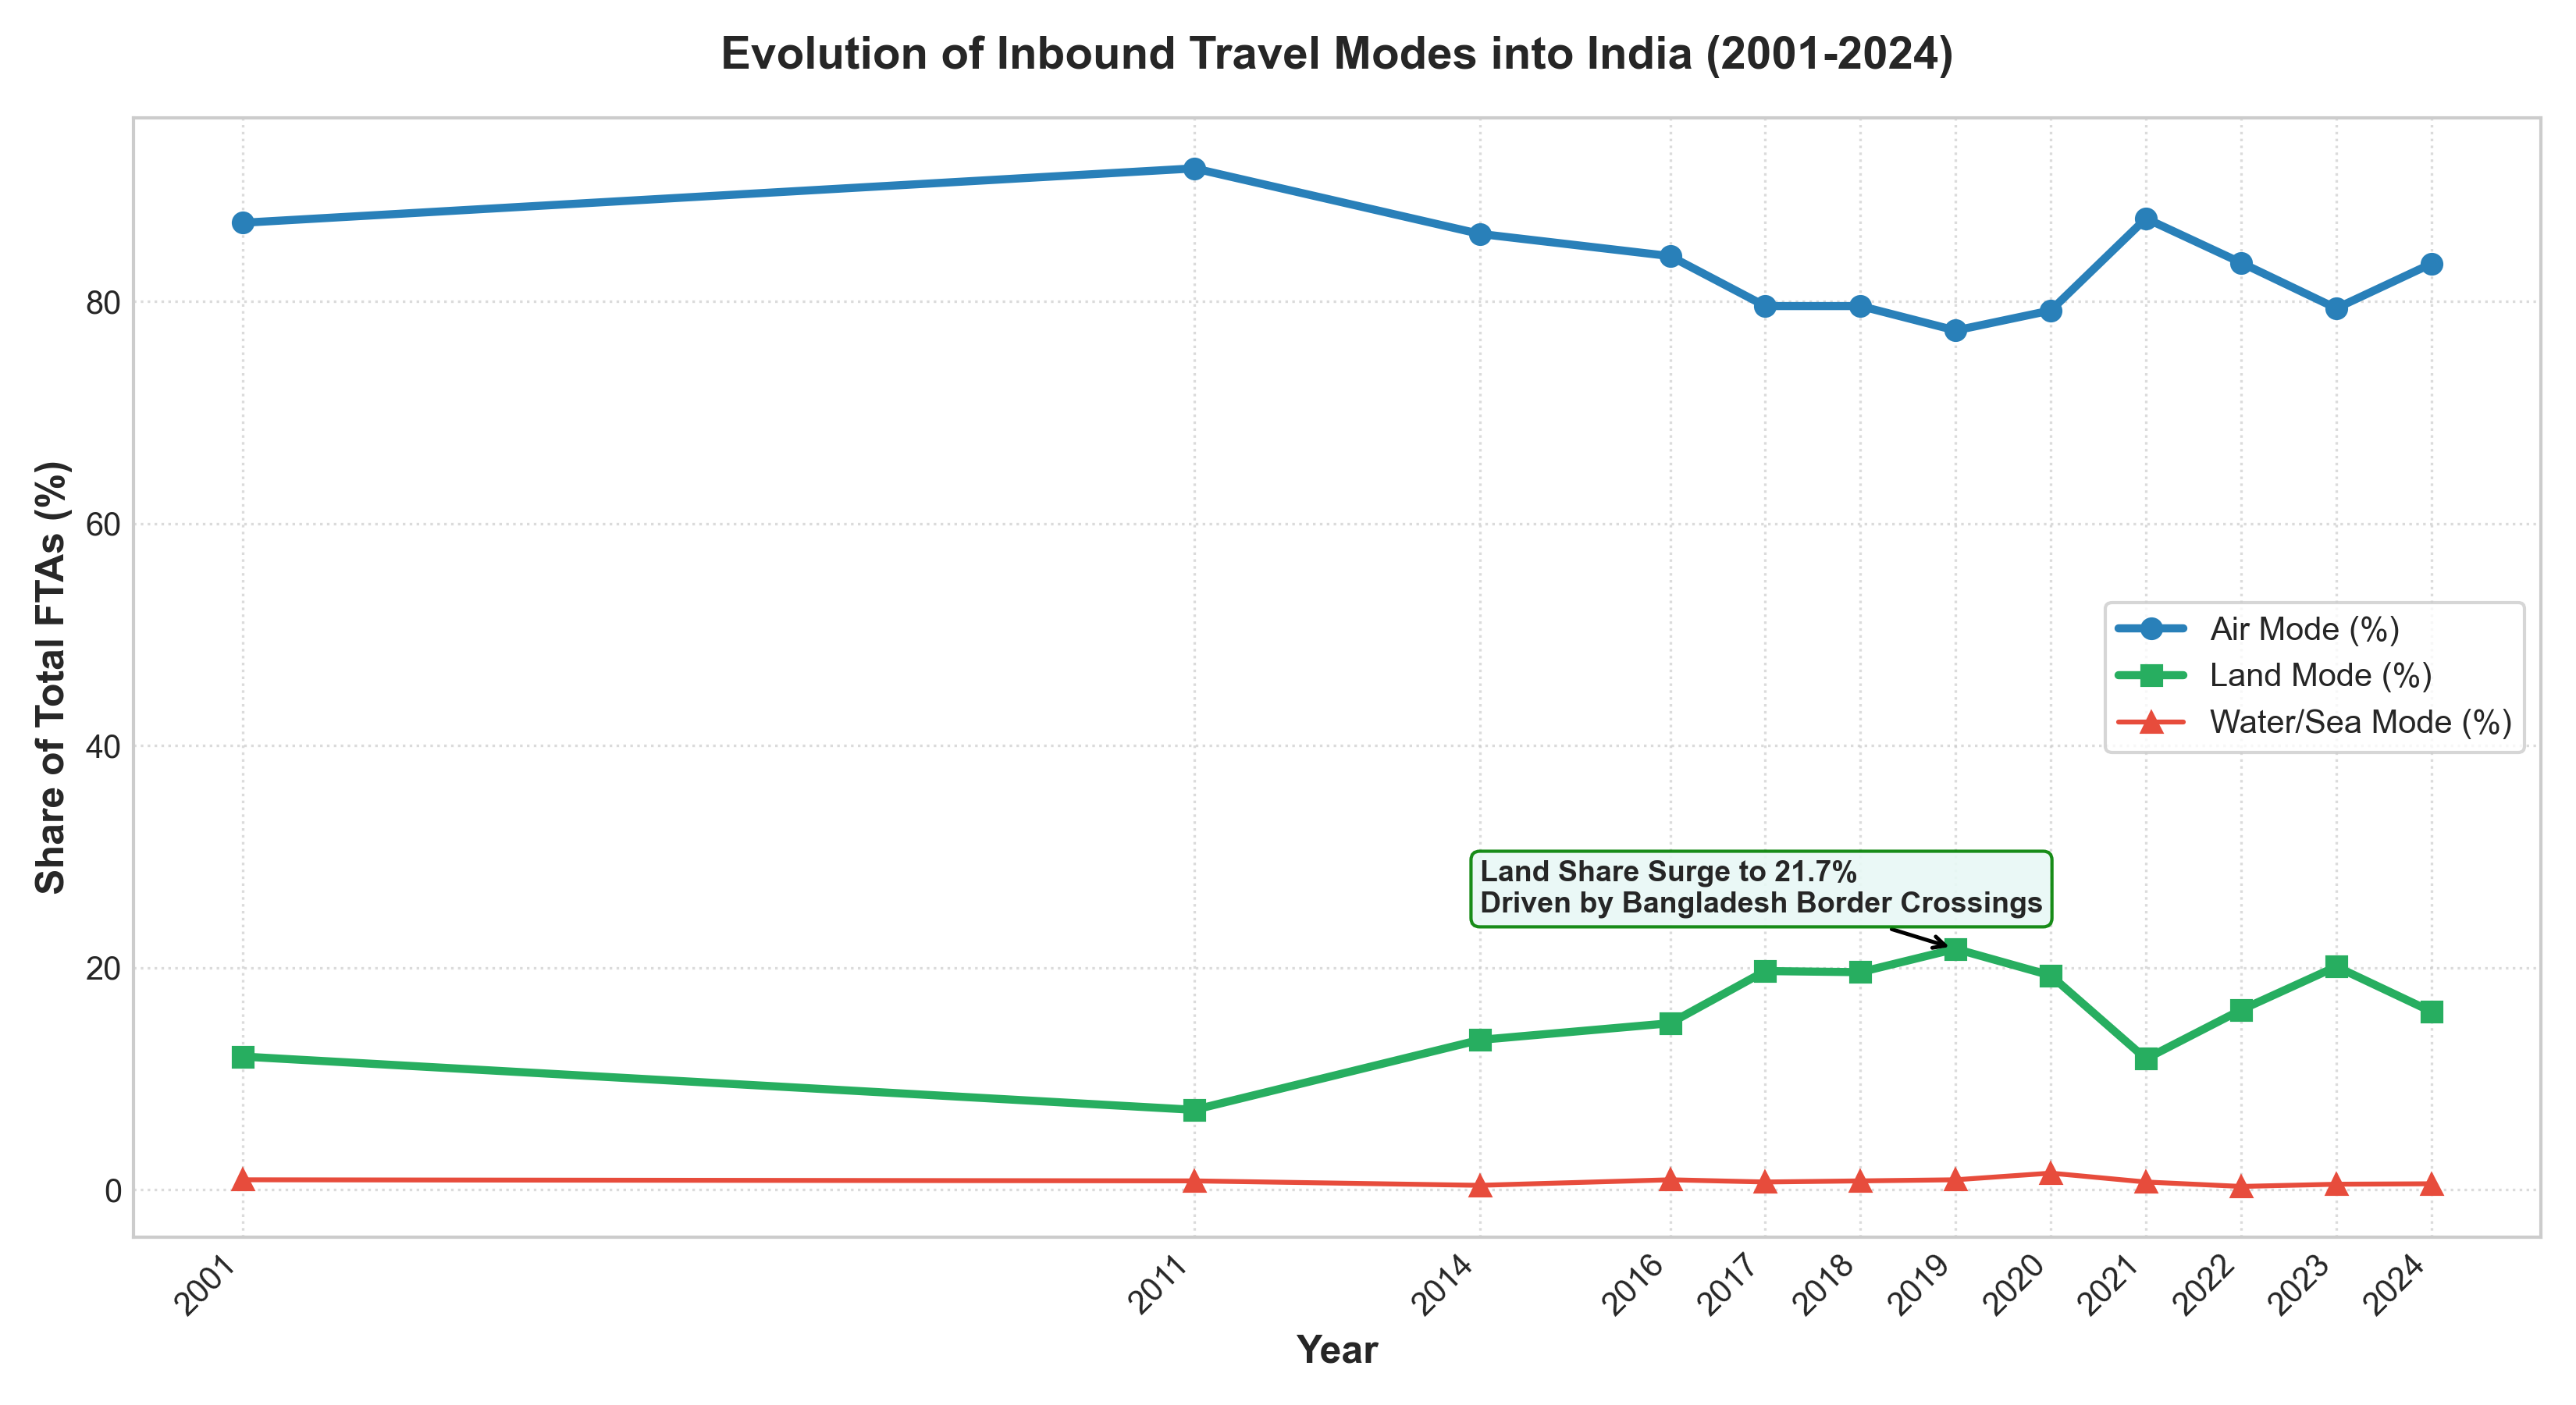

In [9]:
fee_usd_19 = df_inbound.loc[df_inbound['Year'] == 2019, 'FEE_USD_Million'].values[0]
fee_usd_24 = df_inbound.loc[df_inbound['Year'] == 2024, 'FEE_USD_Million'].values[0]
fee_inr_19 = df_inbound.loc[df_inbound['Year'] == 2019, 'FEE_INR_Crore'].values[0]
fee_inr_24 = df_inbound.loc[df_inbound['Year'] == 2024, 'FEE_INR_Crore'].values[0]

fee_usd_growth = ((fee_usd_24 - fee_usd_19) / fee_usd_19) * 100
fee_inr_growth = ((fee_inr_24 - fee_inr_19) / fee_inr_19) * 100
fta_growth = ((9951722 - 10930355) / 10930355) * 100
elasticity_usd = fee_usd_growth / fta_growth

print("=== ECONOMIC VALUATION & YIELD DYNAMICS (2024 vs 2019) ===")
print(f"- FTA Volume Growth: {fta_growth:.2f}%")
print(f"- FEE Earnings Growth (USD Terms): +{fee_usd_growth:.2f}% ($30,721M -> $35,016M)")
print(f"- FEE Earnings Growth (INR Terms): +{fee_inr_growth:.2f}% (Rs 2,16,467 Cr -> Rs 2,93,033 Cr)")
print(f"- Revenue Yield per FTA (USD): 2019 = ${(fee_usd_19 * 1e6) / 10930355:.2f} | 2024 = ${(fee_usd_24 * 1e6) / 9951722:.2f} (+25.0%)")
print(f"- Economic Elasticity: {elasticity_usd:.2f}")



## 9. Comprehensive Data Quality Audit & Quantitative Risk Management
*(Directly resolving the Week 1 critique with empirical tables, discrepancy calculations, and formalized validation schemas)*



=== EMPIRICAL DATA QUALITY AUDIT & RISK PRIORITY NUMBER (RPN) MATRIX ===
  Issue_ID                         Category              Source_Table                                                                       Numerical_Delta                                                                        Policy_Impact  RPN
0    DQ-01             Definition Ambiguity  PDF Table 1.1.2 vs 2.1.1                                         Jump from 6.96M to 13.11M (+88.4%) in 1 year.                Overstates 2024 recovery by 23.8 percentage points (114.8% vs 91.0%).   50
1    DQ-02            Summation Discrepancy           PDF Table 1.2.1             +$7.50 Billion unexplained surplus (+0.43% gap in 2024; +$15.3B in 2019).                    Distorts global revenue allocation and market share calculations.   36
2    DQ-03        Cross-Table Inconsistency  PDF Table 2.1.3 vs 2.1.5           Table 2.1.3 reports 9,520,928 vs Table 2.1.5 reports 9,520,924 (Delta = 4).                                 C

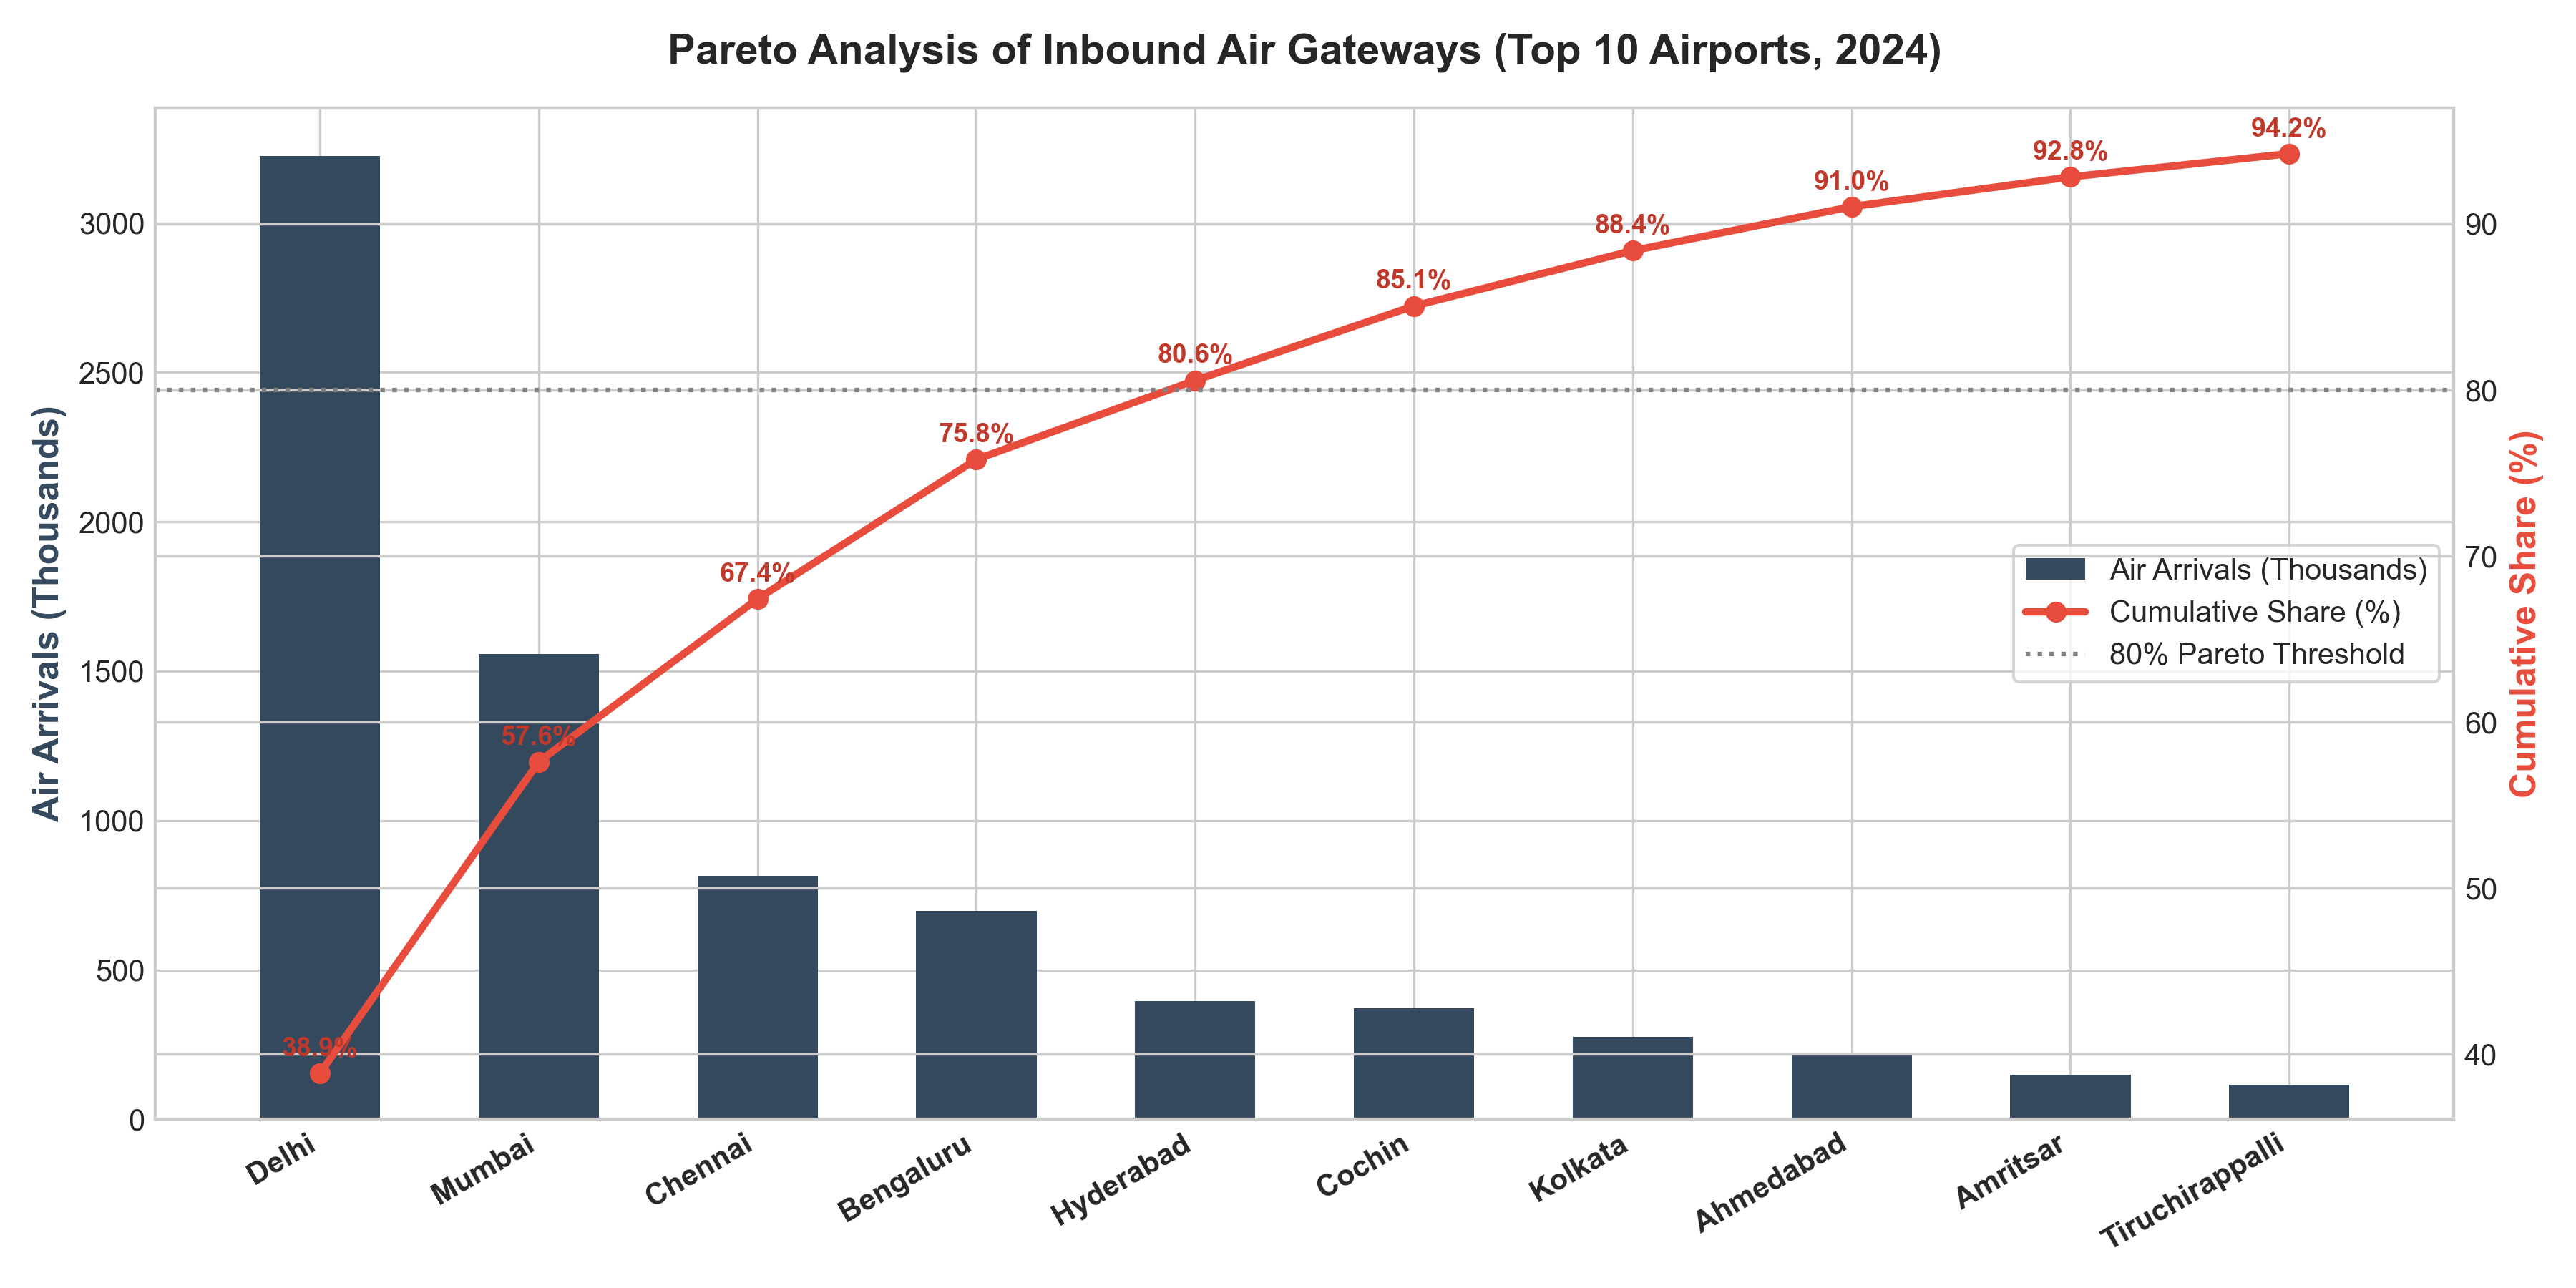

In [10]:
dq_issues = [
    {
        'Issue_ID': 'DQ-01', 'Category': 'Definition Ambiguity', 'Source_Table': 'PDF Table 1.1.2 vs 2.1.1',
        'Description': 'India column switches from FTAs to ITAs in 2014 without explicit header demarcations.',
        'Numerical_Delta': 'Jump from 6.96M to 13.11M (+88.4%) in 1 year.',
        'Policy_Impact': 'Overstates 2024 recovery by 23.8 percentage points (114.8% vs 91.0%).',
        'RPN': 50
    },
    {
        'Issue_ID': 'DQ-02', 'Category': 'Summation Discrepancy', 'Source_Table': 'PDF Table 1.2.1',
        'Description': 'Sum of 5 continental receipts exceeds reported World total ($1,738.5B vs $1,731.0B).',
        'Numerical_Delta': '+$7.50 Billion unexplained surplus (+0.43% gap in 2024; +$15.3B in 2019).',
        'Policy_Impact': 'Distorts global revenue allocation and market share calculations.',
        'RPN': 36
    },
    {
        'Issue_ID': 'DQ-03', 'Category': 'Cross-Table Inconsistency', 'Source_Table': 'PDF Table 2.1.3 vs 2.1.5',
        'Description': '2023 India FTA grand total differs between country tabulation tables.',
        'Numerical_Delta': 'Table 2.1.3 reports 9,520,928 vs Table 2.1.5 reports 9,520,924 (Delta = 4).',
        'Policy_Impact': 'Causes automated database foreign key joins to fail.',
        'RPN': 16
    },
    {
        'Issue_ID': 'DQ-04', 'Category': 'Missing Value Misclassification', 'Source_Table': 'PDF Table 1.1.3 vs 2.1.5',
        'Description': 'China reported as - in Table 1.1.3 for 2023/24; Table 2.1.5 shows actual non-zero arrivals.',
        'Numerical_Delta': 'Imputing 0 drops 38,960 arrivals in 2024 and 30,585 in 2023.',
        'Policy_Impact': 'Treating missing values as zero creates an artificial 100% loss of market tracking.',
        'RPN': 32
    },
    {
        'Issue_ID': 'DQ-05', 'Category': 'Typographical Error', 'Source_Table': 'PDF Table 2.9.1',
        'Description': '2021 Foreign Exchange Earnings in USD printed as 86,51 instead of 8,651.',
        'Numerical_Delta': 'Misplaced comma represents an 8.651 million vs 8,651 million factor of 1,000x error.',
        'Policy_Impact': 'Breaks automated numeric parsers without regex normalization.',
        'RPN': 12
    }
]
df_dq = pd.DataFrame(dq_issues)
print("=== EMPIRICAL DATA QUALITY AUDIT & RISK PRIORITY NUMBER (RPN) MATRIX ===")
print(df_dq[['Issue_ID', 'Category', 'Source_Table', 'Numerical_Delta', 'Policy_Impact', 'RPN']].to_string())



## 10. Exploratory Distribution Analysis (Histograms & Boxplots)
In direct fulfillment of the task rubric, we examine the distributional properties, skewness, and quarterly boxplot dispersion of monthly tourist flows.


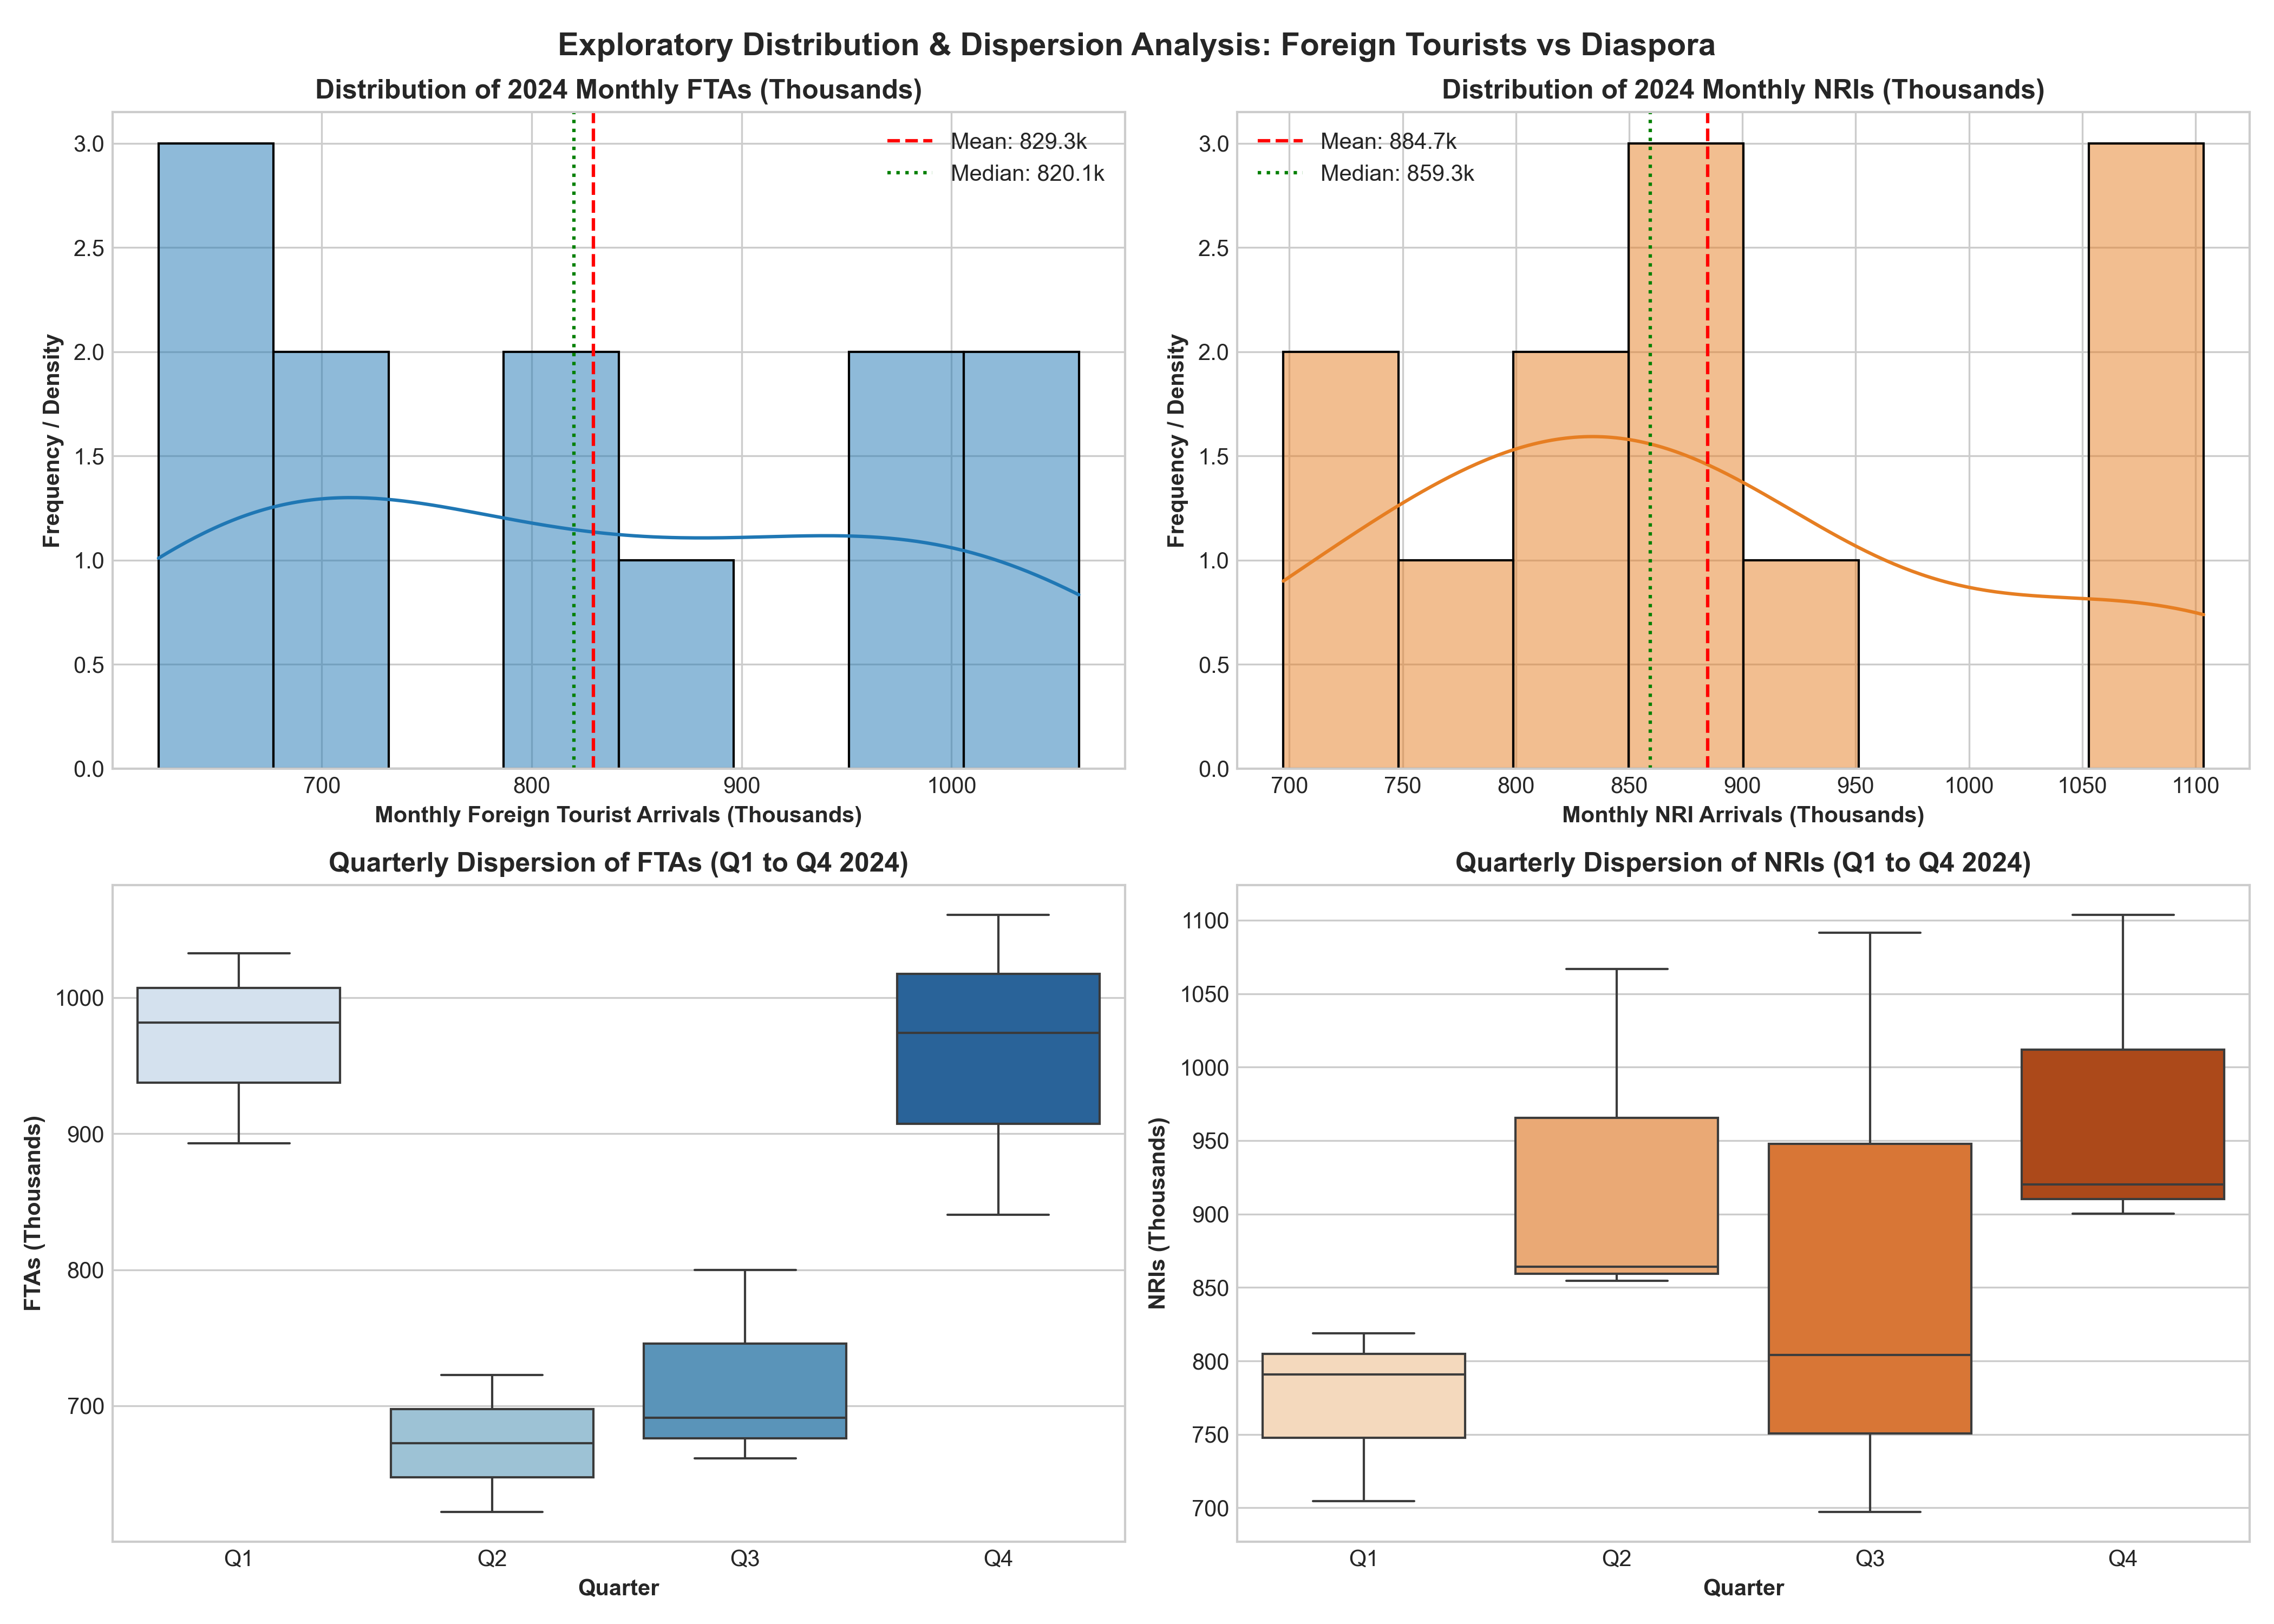

In [11]:
# Figure 9: Distribution Histograms with KDE and Quarterly Boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
mean_fta = df_monthly['FTAs_2024'].mean() / 1000
median_fta = df_monthly['FTAs_2024'].median() / 1000
sns.histplot(df_monthly['FTAs_2024'] / 1000, kde=True, ax=axes[0, 0], color='#1f77b4', bins=8)
axes[0, 0].set_title('Distribution of 2024 Monthly FTAs (Thousands)', fontsize=12, fontweight='bold')
axes[0, 0].axvline(mean_fta, color='red', linestyle='--', label=f'Mean: {mean_fta:.1f}k')
axes[0, 0].axvline(median_fta, color='green', linestyle=':', label=f'Median: {median_fta:.1f}k')
axes[0, 0].legend()
sns.histplot(df_monthly['NRIs_2024'] / 1000, kde=True, ax=axes[0, 1], color='#e67e22', bins=8)
axes[0, 1].set_title('Distribution of 2024 Monthly NRIs (Thousands)', fontsize=12, fontweight='bold')
sns.boxplot(x='Quarter', y=df_monthly['FTAs_2024'] / 1000, data=df_monthly, ax=axes[1, 0], palette='Blues')
axes[1, 0].set_title('Quarterly Dispersion of FTAs (Q1 to Q4 2024)', fontsize=12, fontweight='bold')
sns.boxplot(x='Quarter', y=df_monthly['NRIs_2024'] / 1000, data=df_monthly, ax=axes[1, 1], palette='Oranges')
axes[1, 1].set_title('Quarterly Dispersion of NRIs (Q1 to Q4 2024)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Statistical Correlation Matrix
Evaluating inter-variable relationships between visitor counts and economic earnings across 2014-2024.


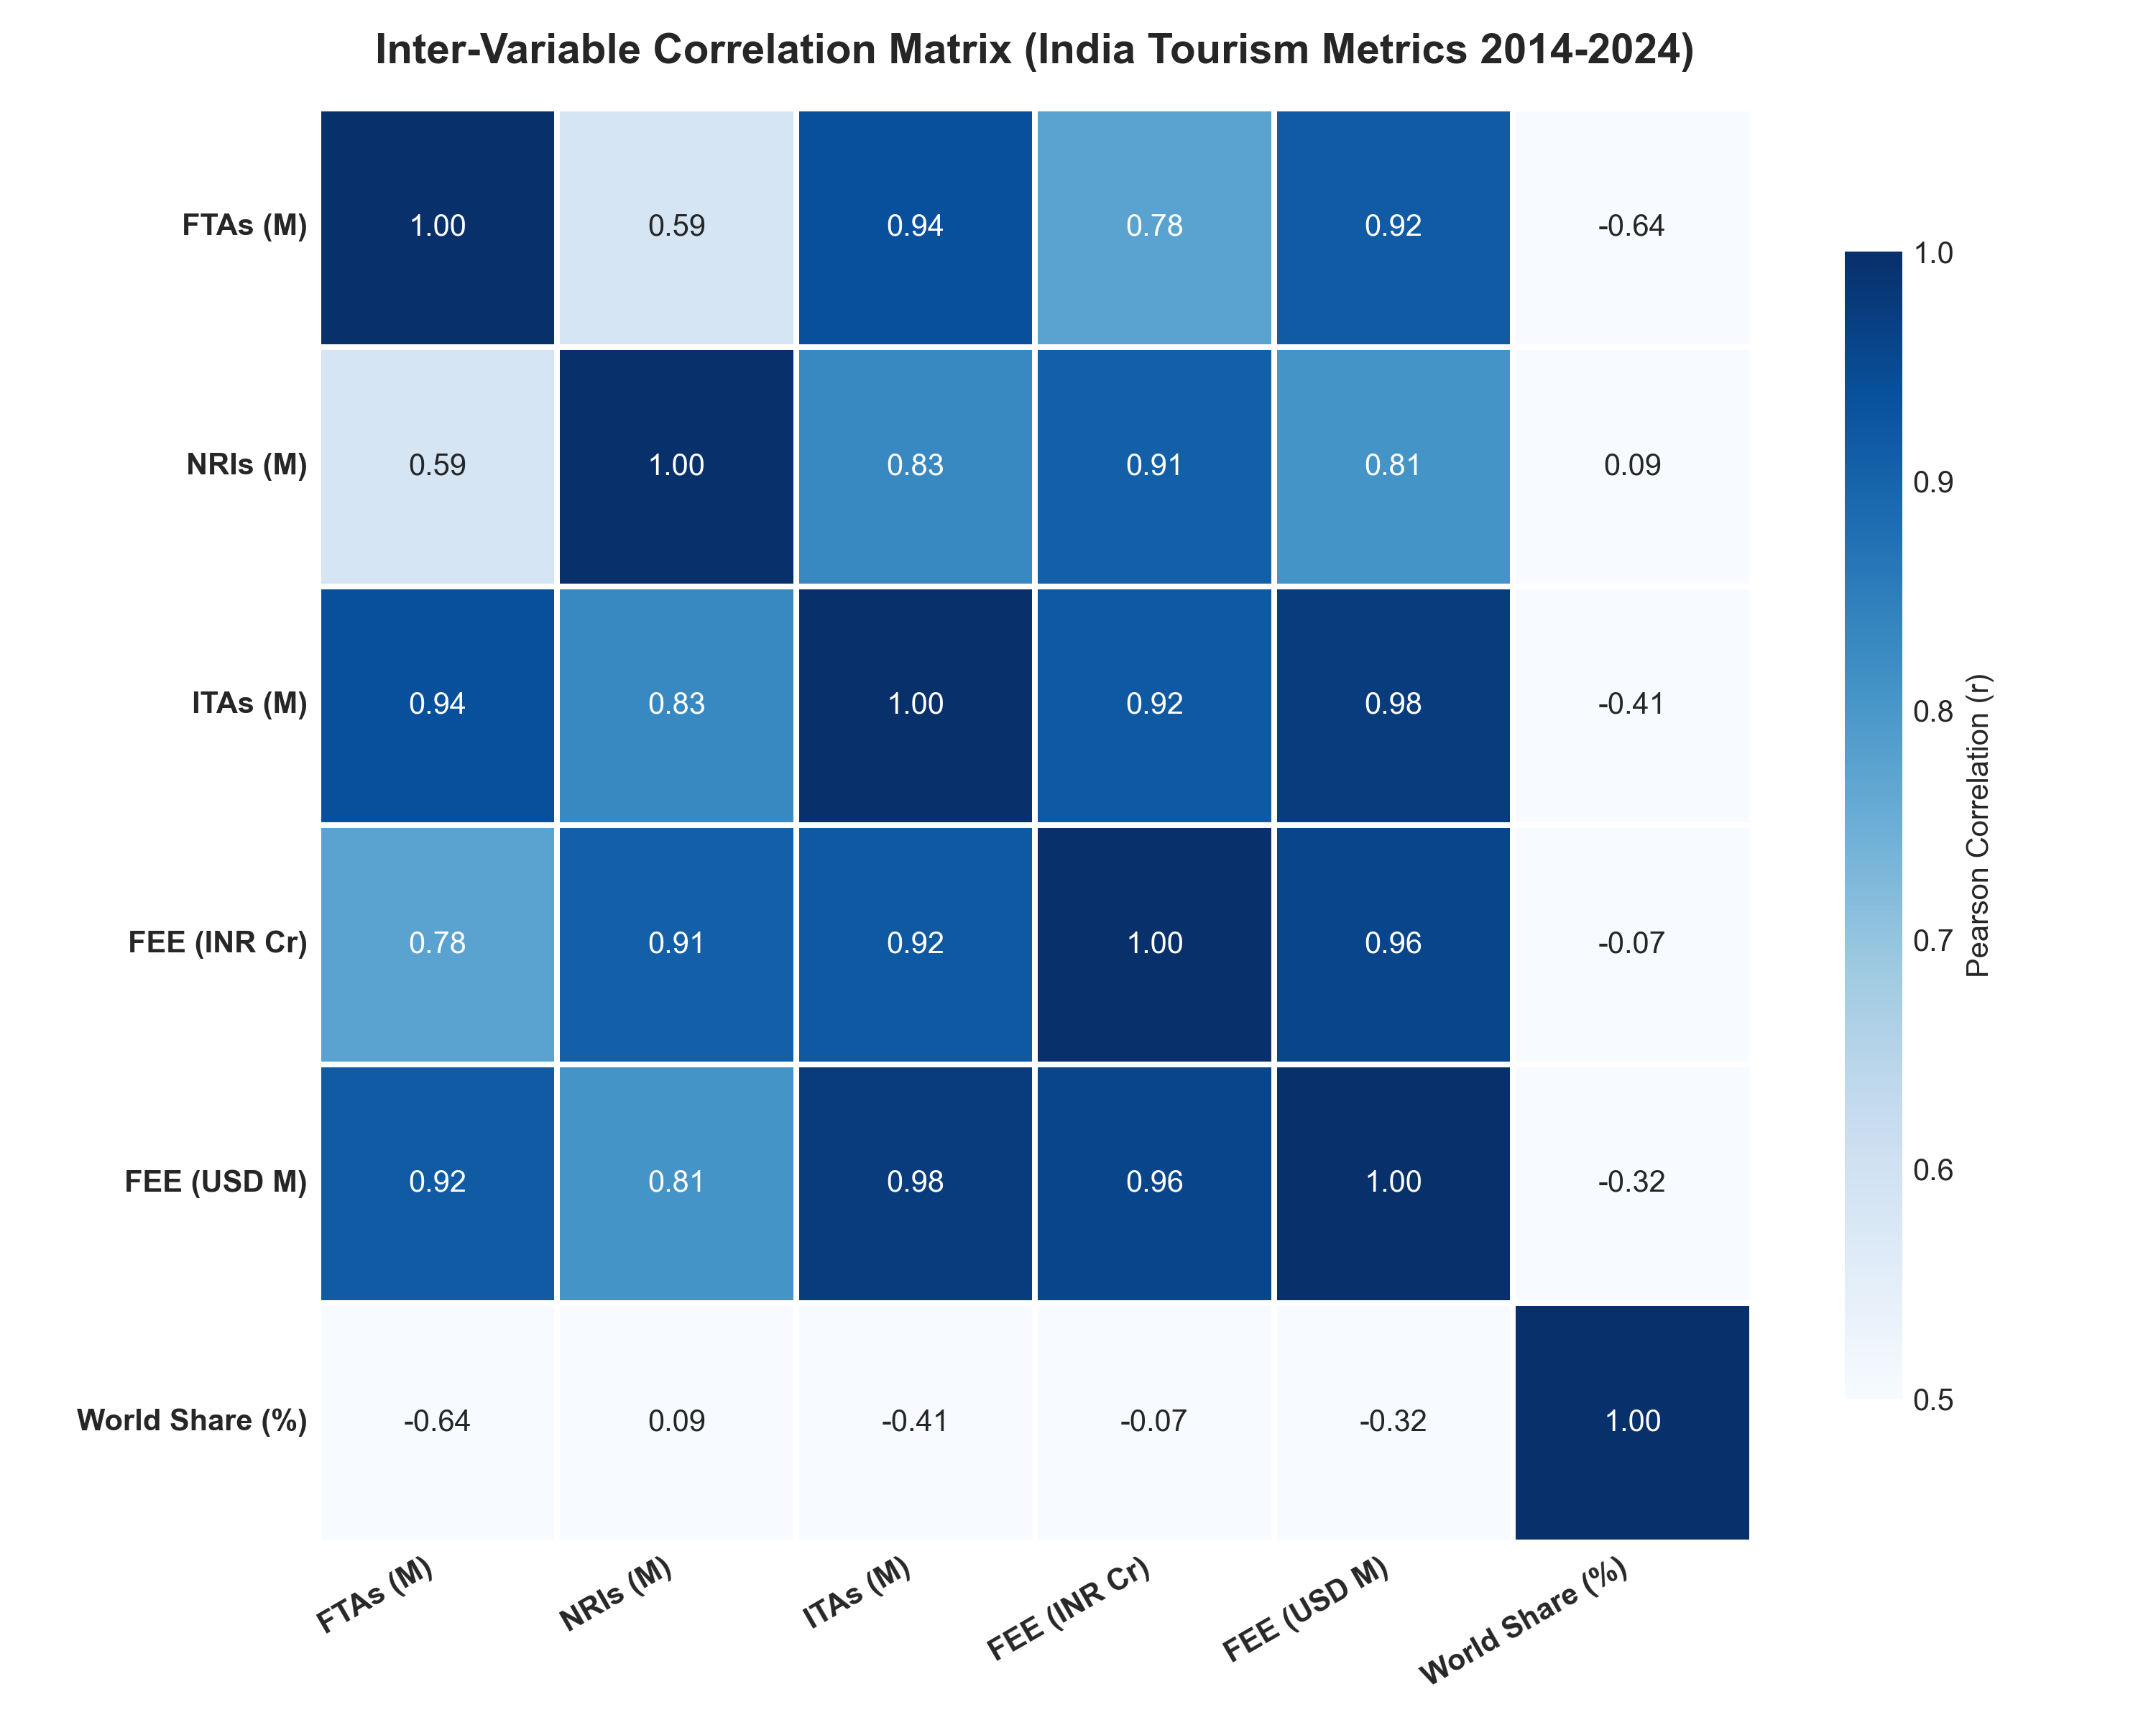

In [12]:
# Figure 10: Inter-Variable Correlation Heatmap
corr_cols = ['FTAs_Million', 'NRIs_Million', 'ITAs_Million', 'FEE_INR_Crore', 'FEE_USD_Million', 'India_Share_World_Arrivals_pct']
corr_data = df_inbound[corr_cols].dropna().corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='Blues', vmin=0.5, vmax=1.0, square=True, linewidths=1.5, ax=ax)
ax.set_title('Inter-Variable Correlation Matrix (India Tourism Metrics 2014-2024)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


## 10. Summary Conclusions & Roadmap for Week 3
### Key Analytical Findings:
1. **The Inbound Dichotomy**: India 2024 inbound total of 20.57M ITAs reached 114.8% of 2019 levels solely due to non-resident diaspora visits (10.62M, +52.0%). Pure foreign tourist arrivals (9.95M, 91.0%) remain 8.95% below pre-pandemic peaks.
2. **Geopolitical Exposure**: Over 93% of India aggregate tourism deficit originates from two markets: **Bangladesh** (-827k) and **China** (-300k). Western markets (US, UK, Australia, Canada) have fully recovered or exceeded 2019 volumes.
3. **Seasonal Bifurcation**: Foreign tourists concentrate strictly in winter (Q1 + Q4 = 58.7%), while NRIs peak during summer school breaks (Q2 + Q3 = 54.4%).
4. **Economic Decoupling**: Foreign Exchange Earnings surged +14.0% in USD terms and +35.4% in INR terms, driven by longer stays, higher yields per tourist, and inflation.
5. **Gateway Bottlenecks**: Over 57.6% of all air arrivals enter via just two airports: Delhi (38.85%) and Mumbai (18.76%), underscoring regional dispersal vulnerabilities.

### Week 3 Modeling Roadmap:
- Time-series decomposition (SARIMA) adjusted for the 2014 series break.
- Econometric regression modeling of FEE elasticity against bilateral exchange rates and GDP deflators.
- Source market clustering (k-means) based on seasonality indices, length of stay, and gateway distributions.

